In [1]:
# ==========================================
# 0. 导包
# ==========================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from lifelines import WeibullFitter, CoxTimeVaryingFitter

import matplotlib.pyplot as plt

d:\Anaconda\envs\python3.10.11\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ==========================================
# 1. 读文件（FD001-FD004 train）
# ==========================================
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 读取所有四个数据集 (FD001-FD004)
file_paths = [
    'CMAPSSData/train_FD001.txt',
    'CMAPSSData/train_FD002.txt',
    'CMAPSSData/train_FD003.txt',
    'CMAPSSData/train_FD004.txt'
]

df_list = []
unit_offset = 0  # 用于给不同数据集的引擎编号加偏移，避免ID冲突

for i, file_path in enumerate(file_paths):
    df_temp = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)
    # 给unit_nr加上偏移量，避免不同数据集的引擎ID冲突
    df_temp['unit_nr'] = df_temp['unit_nr'] + unit_offset
    df_temp['dataset'] = f'FD00{i+1}'  # 标记数据来源
    unit_offset = df_temp['unit_nr'].max()  # 更新偏移量
    df_list.append(df_temp)
    print(f"成功读取文件: {file_path}, 行数: {len(df_temp)}")

# 合并所有数据集
df = pd.concat(df_list, ignore_index=True)
print(f"\n合并完成！总数据行数: {len(df)}, 总引擎数: {df['unit_nr'].nunique()}")
print(df.head())

成功读取文件: CMAPSSData/train_FD001.txt, 行数: 20631
成功读取文件: CMAPSSData/train_FD002.txt, 行数: 53759
成功读取文件: CMAPSSData/train_FD003.txt, 行数: 24720
成功读取文件: CMAPSSData/train_FD004.txt, 行数: 61249

合并完成！总数据行数: 160359, 总引擎数: 709
   unit_nr  time_cycles  setting_1  setting_2  setting_3     SM1     SM2  \
0        1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1        1            2     0.0019    -0.0003      100.0  518.67  642.15   
2        1            3    -0.0043     0.0003      100.0  518.67  642.35   
3        1            4     0.0007     0.0000      100.0  518.67  642.35   
4        1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       SM3      SM4    SM5  ...     SM13     SM14    SM15  SM16  SM17  SM18  \
0  1589.70  1400.60  14.62  ...  2388.02  8138.62  8.4195  0.03   392  2388   
1  1591.82  1403.14  14.62  ...  2388.07  8131.49  8.4318  0.03   392  2388   
2  1587.99  1404.20  14.62  ...  2388.03  8133.23  8.4178  0.03   390  2388   
3  1582.79  

In [4]:
# ==========================================
# 2. 选择论文 14 个传感器
# ==========================================
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

df_process = df[index_names + selected_features].copy()

In [5]:
# ==========================================
# 3. Min-Max 归一化（全训练集口径）
# ==========================================
scaler = MinMaxScaler()
df_process[selected_features] = scaler.fit_transform(df_process[selected_features])

print("MinMax done.")

MinMax done.


In [6]:
# ==========================================
# 4. 构建 lifelines CoxTimeVaryingFitter 所需长表
#    start=t-1, stop=t，最后一个cycle event=1
# ==========================================
df_process['start'] = df_process['time_cycles'] - 1
df_process['stop']  = df_process['time_cycles']

max_cycles = df_process.groupby('unit_nr')['time_cycles'].max()

df_process['E'] = (df_process['time_cycles'] == df_process['unit_nr'].map(max_cycles)).astype(int)

print("Long format done:",
      "rows =", len(df_process),
      "units =", df_process['unit_nr'].nunique())
print(df_process[['unit_nr','time_cycles','start','stop','E']].head())

Long format done: rows = 160359 units = 709
   unit_nr  time_cycles  start  stop  E
0        1            1      0     1  0
1        1            2      1     2  0
2        1            3      2     3  0
3        1            4      3     4  0
4        1            5      4     5  0


In [7]:
# ==========================================
# 5. 拟合 Weibull（得到 BH 参数 β, η）
#    使用每台发动机寿命 T = max_cycle，FD001 train 为 run-to-failure => E=1
# ==========================================
durations = max_cycles.values.astype(float)
events = np.ones_like(durations, dtype=int)

wb = WeibullFitter()
wb.fit(durations=durations, event_observed=events)

beta = float(wb.rho_)      # shape
eta  = float(wb.lambda_)   # scale

print("\nWeibull fitted:")
print("beta (shape) =", beta)
print("eta  (scale) =", eta)

# 计算每一行的 Baseline Hazard BH(t) = (beta/eta) * (t/eta)^(beta-1)
t = df_process['time_cycles'].astype(float).values
BH = (beta / eta) * (t / eta) ** (beta - 1.0)
df_process['BH'] = BH


Weibull fitted:
beta (shape) = 3.3643965081691114
eta  (scale) = 250.6644684311487


In [8]:
# ==========================================
# 6. 拟合 time-varying Cox（得到 HR）
#    关键：predict_partial_hazard 只喂 14 个传感器列
# ==========================================
ctv = CoxTimeVaryingFitter(penalizer=0.0)  # 若你觉得不稳定可改 1e-3 或 1e-2
ctv.fit(
    df_process[['unit_nr','start','stop','E'] + selected_features],
    id_col='unit_nr',
    start_col='start',
    stop_col='stop',
    event_col='E',
    show_progress=True
)

print("\nCox TV fitted. Top params:")
print(ctv.params_.sort_values(ascending=False))

HR = ctv.predict_partial_hazard(df_process[selected_features]).values.astype(float)
df_process['HR'] = HR

# hazard_rate（可选，后续不用于聚类）
df_process['hazard_rate'] = df_process['BH'] * df_process['HR']

Iteration 1: norm_delta = 1.06e+02, step_size = 0.9500, log_lik = -3948.97455, newton_decrement = 1.10e+03, seconds_since_start = 1.5
Iteration 2: norm_delta = 4.01e+00, step_size = 0.0950, log_lik = -2745.37331, newton_decrement = 1.75e+02, seconds_since_start = 2.5
Iteration 3: norm_delta = 4.84e+00, step_size = 0.1235, log_lik = -2713.75611, newton_decrement = 1.54e+02, seconds_since_start = 3.7
Iteration 4: norm_delta = 5.57e+00, step_size = 0.1573, log_lik = -2677.92320, newton_decrement = 1.32e+02, seconds_since_start = 4.6
Iteration 5: norm_delta = 1.54e+00, step_size = 0.0501, log_lik = -2639.67034, newton_decrement = 1.07e+02, seconds_since_start = 5.6
Iteration 6: norm_delta = 1.88e+00, step_size = 0.0638, log_lik = -2629.18649, newton_decrement = 1.01e+02, seconds_since_start = 6.5
Iteration 7: norm_delta = 2.26e+00, step_size = 0.0813, log_lik = -2616.73677, newton_decrement = 9.28e+01, seconds_since_start = 7.5
Iteration 8: norm_delta = 2.68e+00, step_size = 0.1036, log_li

In [9]:
# ==========================================
# 7. 构造聚类输入：BH + log(HR)
#    用 log(HR) 是为了抑制指数爆炸；然后做 MinMax scaling
# ==========================================
logHR = np.log(df_process['HR'].values + 1e-12)
df_process['logHR'] = logHR

# scaling（全体样本口径）
bh_scaler = MinMaxScaler()
hr_scaler = MinMaxScaler()

df_process['BH_scaled'] = bh_scaler.fit_transform(df_process[['BH']]).ravel()
df_process['logHR_scaled'] = hr_scaler.fit_transform(df_process[['logHR']]).ravel()

print("\nScaled features ready:")
print(df_process[['BH','HR','logHR','BH_scaled','logHR_scaled']].head())


Scaled features ready:
             BH        HR     logHR  BH_scaled  logHR_scaled
0  2.853697e-08  0.387155 -0.948931   0.000000      0.536872
1  1.469475e-07  0.900289 -0.105040   0.000001      0.567316
2  3.832760e-07  0.157547 -1.848034   0.000004      0.504437
3  7.566871e-07  0.107213 -2.232941   0.000009      0.490551
4  1.282478e-06  0.405154 -0.903488   0.000015      0.538511


In [10]:
# ==========================================
# 8. KMeans：分别对 BH_scaled 与 logHR_scaled 做 2 类聚类（论文结构）
#    目标：输出 BH_state ∈ {0(low),1(high)}，HR_state ∈ {0(low),1(high)}
# ==========================================
def kmeans_2class_high_is_1(x_1d, random_state=42):
    """
    对一维特征做 KMeans(2类)，并强制：均值更大的那类记为 1（高风险），更小为 0（低风险）
    """
    x_1d = np.asarray(x_1d).reshape(-1, 1)
    km = KMeans(n_clusters=2, random_state=random_state, n_init='auto')
    labels = km.fit_predict(x_1d)
    centers = km.cluster_centers_.ravel()

    high_cluster = int(np.argmax(centers))
    # 映射到 {0,1} 且 high=1
    labels_high1 = (labels == high_cluster).astype(int)
    return labels_high1, km

df_process['BH_state'], km_bh = kmeans_2class_high_is_1(df_process['BH_scaled'].values)
df_process['HR_state'], km_hr = kmeans_2class_high_is_1(df_process['logHR_scaled'].values)

print("\nKMeans centers:")
print("BH centers:", km_bh.cluster_centers_.ravel())
print("HR centers:", km_hr.cluster_centers_.ravel())

print(df_process[['BH_scaled','logHR_scaled','BH_state','HR_state']].head())


KMeans centers:
BH centers: [0.032474   0.25125047]
HR centers: [0.41451431 0.66109897]
   BH_scaled  logHR_scaled  BH_state  HR_state
0   0.000000      0.536872         0         0
1   0.000001      0.567316         0         1
2   0.000004      0.504437         0         0
3   0.000009      0.490551         0         0
4   0.000015      0.538511         0         1


In [11]:
# ==========================================
# 9. 合成 3 类健康状态（论文规则）
#    Healthy=2, Warning=1, Failure=0
# ==========================================
def combine_state(bh_state, hr_state):
    # bh_state, hr_state: 0(low) or 1(high)
    if bh_state == 0 and hr_state == 0:
        return 2  # Healthy
    if bh_state == 1 and hr_state == 1:
        return 0  # Failure
    return 1      # Warning

df_process['Health'] = [
    combine_state(bh, hr) for bh, hr in zip(df_process['BH_state'], df_process['HR_state'])
]

print("\nHealth label counts:")
print(df_process['Health'].value_counts().sort_index())


Health label counts:
Health
0    11677
1    93404
2    55278
Name: count, dtype: int64


In [12]:
# ==========================================
# 10. 强制末段 failure（论文有这一手；d 论文未明说，先用 5）
# ==========================================
d = 5
for unit in df_process['unit_nr'].unique():
    idx = (df_process[df_process['unit_nr'] == unit]
           .sort_values('time_cycles')
           .tail(d)
           .index)
    df_process.loc[idx, 'Health'] = 0

print("\nHealth label counts after tail-forcing:")
print(df_process['Health'].value_counts().sort_index())


Health label counts after tail-forcing:
Health
0    14179
1    91109
2    55071
Name: count, dtype: int64


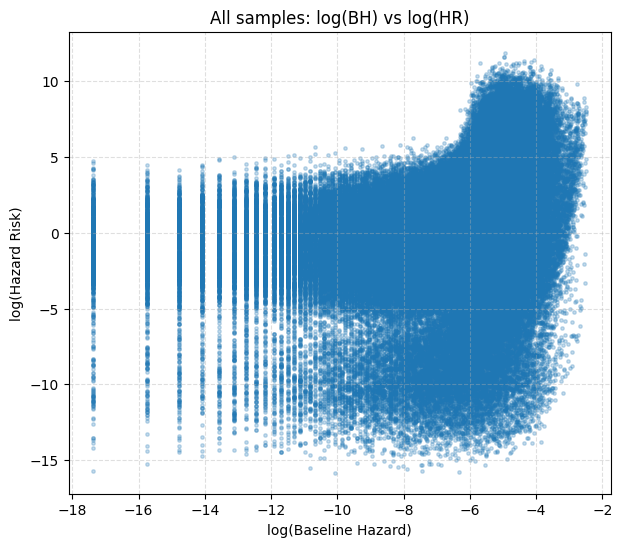

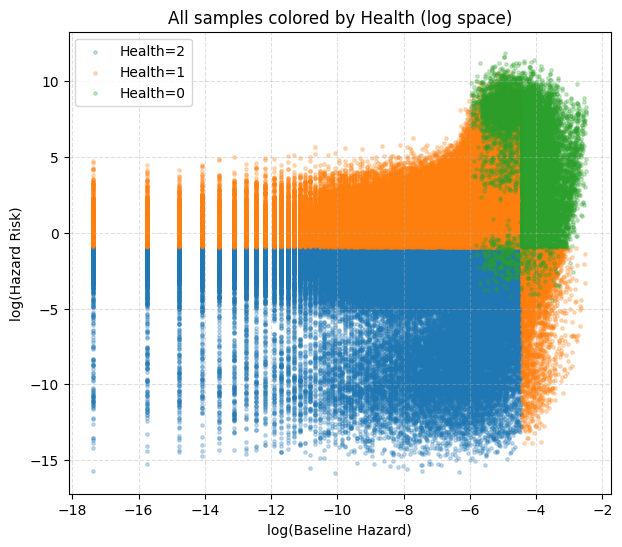

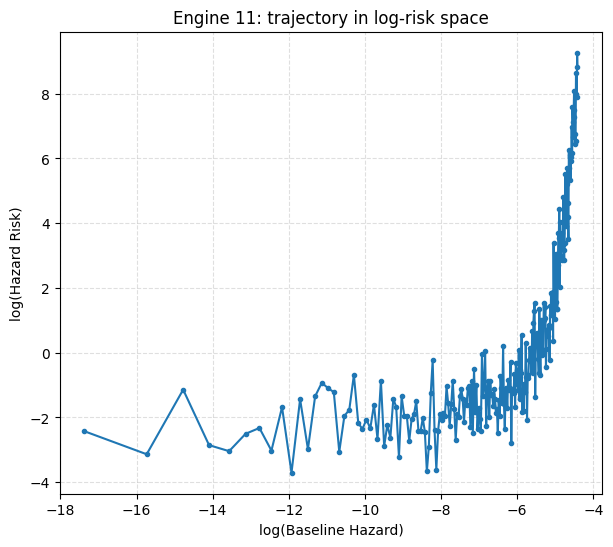

In [13]:
# ==========================================
# 11. 可视化：BH_scaled vs logHR_scaled（全体点 + 选定 engine）
# ==========================================
# 全体散点
plt.figure(figsize=(7, 6))
plt.scatter(
    np.log(df_process['BH'] + 1e-30),
    np.log(df_process['HR'] + 1e-12),
    s=6,
    alpha=0.25
)
plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples: log(BH) vs log(HR)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# 按健康状态着色（颜色不指定也行，但这里为了区分更直观）
plt.figure(figsize=(7, 6))
for label in [2, 1, 0]:
    sub = df_process[df_process['Health'] == label]
    plt.scatter(
        np.log(sub['BH'] + 1e-30),
        np.log(sub['HR'] + 1e-12),
        s=6,
        alpha=0.25,
        label=f"Health={label}"
    )

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples colored by Health (log space)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# 单独看 Engine 11 的轨迹
engine_id = 11
sub11 = df_process[df_process['unit_nr'] == engine_id].sort_values('time_cycles')

plt.figure(figsize=(7, 6))
plt.plot(
    np.log(sub11['BH'] + 1e-30),
    np.log(sub11['HR'] + 1e-12),
    linewidth=1.5,
    marker='o',
    markersize=3
)

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title(f"Engine {engine_id}: trajectory in log-risk space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [14]:
df_process.groupby('Health')[['BH','HR']].median()


,BH,HR
Health,,
0,0.015860,91.379378
1,0.002306,5.423151
2,0.000875,0.044197


# 监督学习

In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


# 14 个传感器
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

# 监督学习输入/标签/分组
X = df_process[selected_features].values
y = df_process['Health'].values.astype(int)
groups = df_process['unit_nr'].values  # 按发动机分组切分（关键）

print("X shape:", X.shape, "y dist:", pd.Series(y).value_counts().sort_index().to_dict())
print("n_engines:", df_process['unit_nr'].nunique())


X shape: (160359, 14) y dist: {0: 14179, 1: 91109, 2: 55071}
n_engines: 709


In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train, g_test = groups[train_idx], groups[test_idx]

print("train engines:", len(np.unique(g_train)), "test engines:", len(np.unique(g_test)))
print("train y dist:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("test  y dist:", pd.Series(y_test).value_counts().sort_index().to_dict())


train engines: 567 test engines: 142
train y dist: {0: 12028, 1: 71570, 2: 45721}
test  y dist: {0: 2151, 1: 19539, 2: 9350}


In [17]:
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto"))
])

clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.2720    0.7434    0.3983      2151
           1     0.9265    0.7195    0.8100     19539
           2     0.8727    0.9322    0.9015      9350

    accuracy                         0.7852     31040
   macro avg     0.6904    0.7984    0.7032     31040
weighted avg     0.8649    0.7852    0.8090     31040

Confusion matrix:
 [[ 1599   488    64]
 [ 4274 14058  1207]
 [    6   628  8716]]


In [18]:
clf_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=None
)

clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.6587    0.4486    0.5337      2151
           1     0.9213    0.9454    0.9332     19539
           2     0.9370    0.9543    0.9456      9350

    accuracy                         0.9137     31040
   macro avg     0.8390    0.7828    0.8042     31040
weighted avg     0.9078    0.9137    0.9092     31040

Confusion matrix:
 [[  965  1161    25]
 [  491 18473   575]
 [    9   418  8923]]


SM11    0.132047
SM13    0.100177
SM15    0.084784
SM4     0.078480
SM8     0.076703
SM2     0.074164
SM12    0.072692
SM14    0.070382
SM7     0.059850
SM9     0.053904
SM3     0.053147
SM21    0.049728
SM20    0.048666
SM17    0.045276
dtype: float64


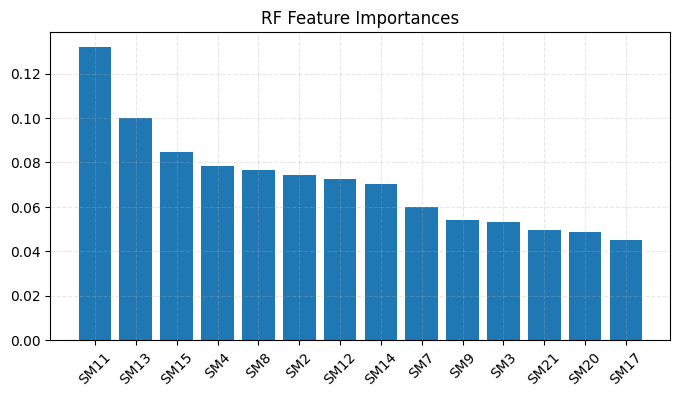

In [19]:
importances = pd.Series(clf_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45)
plt.title("RF Feature Importances")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


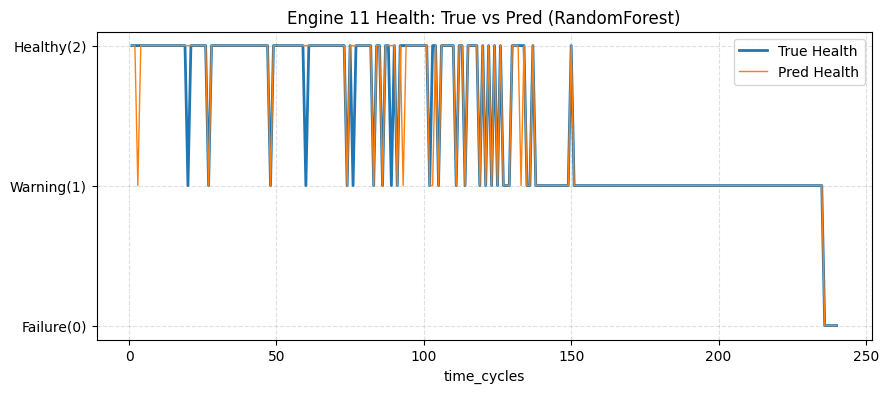

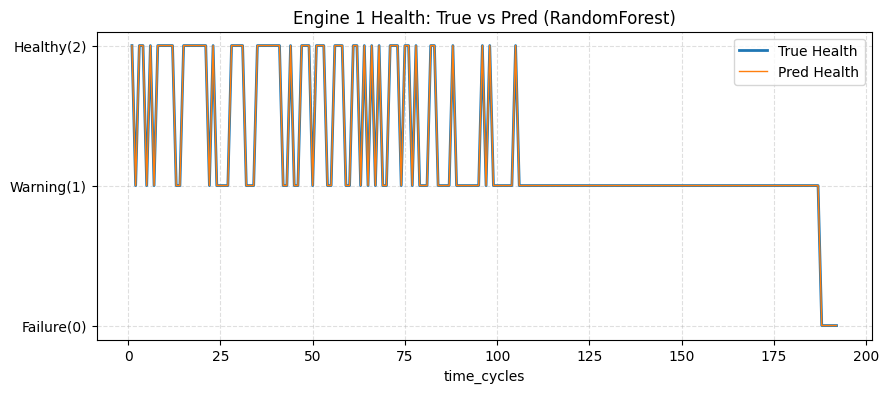

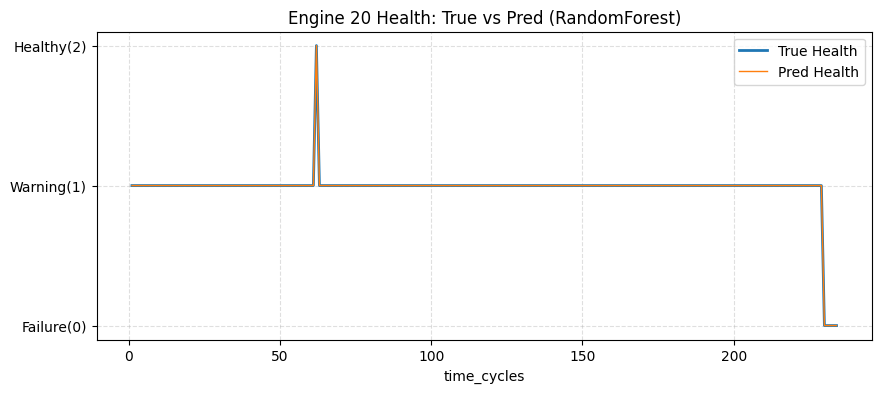

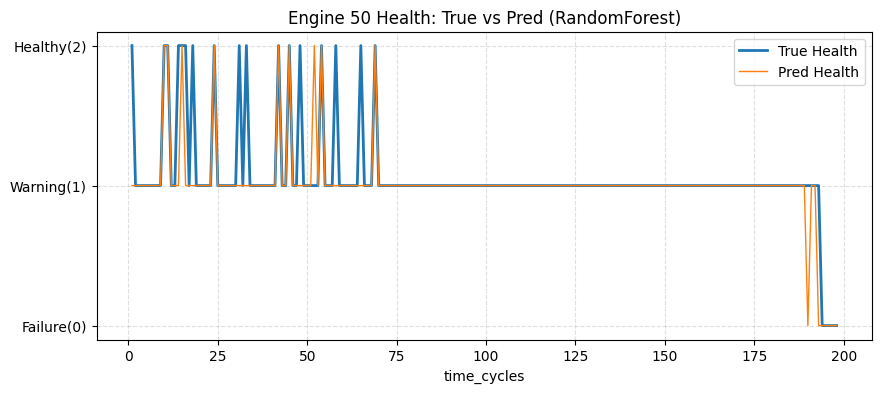

In [20]:
def plot_engine_pred(engine_id, model, title_suffix=""):
    sub = df_process[df_process["unit_nr"] == engine_id].sort_values("time_cycles")
    X_sub = sub[selected_features].values
    y_true = sub["Health"].values.astype(int)
    y_pred = model.predict(X_sub)

    plt.figure(figsize=(10,4))
    plt.plot(sub["time_cycles"], y_true, label="True Health", linewidth=2)
    plt.plot(sub["time_cycles"], y_pred, label="Pred Health", linewidth=1)
    plt.yticks([0,1,2], ["Failure(0)","Warning(1)","Healthy(2)"])
    plt.xlabel("time_cycles")
    plt.title(f"Engine {engine_id} Health: True vs Pred {title_suffix}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

# 选几个发动机看看（包含 11）
for eid in [11, 1, 20, 50]:
    plot_engine_pred(eid, clf_rf, "(RandomForest)")


In [21]:
# ======== 强制对齐论文的 state 编码 ========
# paper: 0=Healthy, 1=Warning, 2=Failure

health_map = {
    2: 0,  # Healthy -> 0
    1: 1,  # Warning -> 1
    0: 2   # Failure -> 2
}

df_process['Health_RL'] = df_process['Health'].map(health_map).astype(int)

print("Health (old) -> Health_RL (paper-aligned) counts:")
print(df_process[['Health', 'Health_RL']].value_counts().sort_index())


Health (old) -> Health_RL (paper-aligned) counts:
Health  Health_RL
0       2            14179
1       1            91109
2       0            55071
Name: count, dtype: int64


In [22]:
import numpy as np
import pandas as pd

# paper-aligned state: 0=Healthy, 1=Warning, 2=Failure
assert set(df_process["Health_RL"].unique()).issubset({0,1,2})

# 统计 n_ij：同一台发动机相邻时刻的状态转移
df_sorted = df_process.sort_values(["unit_nr", "time_cycles"]).copy()
df_sorted["next_state"] = df_sorted.groupby("unit_nr")["Health_RL"].shift(-1)

pairs = df_sorted.dropna(subset=["next_state"]).copy()
pairs["next_state"] = pairs["next_state"].astype(int)

n_ij = np.zeros((3,3), dtype=int)
for i, j in zip(pairs["Health_RL"].values.astype(int), pairs["next_state"].values.astype(int)):
    n_ij[i, j] += 1

row_sums = n_ij.sum(axis=1, keepdims=True)
P0 = np.divide(n_ij, row_sums, out=np.zeros_like(n_ij, dtype=float), where=row_sums!=0)

print("n_ij counts:\n", n_ij)
print("\nP0 (no repair) from data (Eq.11):\n", np.round(P0, 5))
print("\nRow sums:", P0.sum(axis=1))


n_ij counts:
 [[33980 21012    79]
 [20737 68070  2302]
 [    0  1672 11798]]

P0 (no repair) from data (Eq.11):
 [[0.61702 0.38154 0.00143]
 [0.22761 0.74713 0.02527]
 [0.      0.12413 0.87587]]

Row sums: [1. 1. 1.]


In [23]:
# ===== 修正 P1 (小修) 转移矩阵 =====
# 论文语义：小修是"不完美修复"，应该能改善状态但不能完全恢复
# 关键修正：小修对 Failure 状态应该有一定效果（比如恢复到 Warning）

P1 = np.zeros((3,3), dtype=float)
P2 = np.zeros((3,3), dtype=float)

# minor repair: 不完美修复
# Healthy -> 保持 Healthy（小修对健康状态没必要但无害）
P1[0,0] = 1.0
# Warning -> 有 80% 概率恢复 Healthy，20% 留在 Warning
P1[1,0] = 0.8
P1[1,1] = 0.2
# Failure -> 小修只能部分恢复：70% 到 Warning，30% 留在 Failure
P1[2,1] = 0.7
P1[2,2] = 0.3

# major repair: 完美修复，总是恢复到 Healthy
P2[0,0] = 1.0
P2[1,0] = 1.0
P2[2,0] = 1.0

print("P1 (minor repair) - 修正后:\n", P1)
print("\nP2 (major repair):\n", P2)

P1 (minor repair) - 修正后:
 [[1.  0.  0. ]
 [0.8 0.2 0. ]
 [0.  0.7 0.3]]

P2 (major repair):
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [ ]:
import numpy as np
import random

# =========================
# 0) You must define P0, P1, P2 before running this cell
#    Each is a 3x3 transition matrix: P[a][s, s_next]
# =========================
try:
    P0; P1; P2
except NameError as e:
    raise NameError("Please define P0, P1, P2 (each 3x3) before running this code.") from e

def _check_transition_matrix(P, name):
    P = np.array(P, dtype=float)
    if P.shape != (3, 3):
        raise ValueError(f"{name} must be shape (3,3), got {P.shape}")
    row_sums = P.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-6):
        raise ValueError(f"{name} rows must sum to 1. Row sums = {row_sums}")
    if np.any(P < -1e-12):
        raise ValueError(f"{name} has negative probabilities.")
    return P

P0 = _check_transition_matrix(P0, "P0")
P1 = _check_transition_matrix(P1, "P1")
P2 = _check_transition_matrix(P2, "P2")

# =========================
# 1) Costs / Rewards
# =========================
R_action = np.array([0.0, -20.0, -40.0])  # a=0,1,2
state_cost = {0: 0.0, 1: -5.0, 2: -10.0}

# =========================
# 2) Hyperparams
# =========================
N_total = 200
iters_per_epoch = 400  # max steps per episode (但 major repair 会提前终止)
gamma = 0.99
lr = 0.01

eps_min = 1.0 / N_total
eps_max = 1.0
eps_decay = -0.1

def epsilon(epoch_idx):
    return eps_min + (eps_max - eps_min) * np.exp(eps_decay * epoch_idx)

# =========================
# 3) MDP definition
# =========================
P_by_action = [P0, P1, P2]

# 【论文口径】不做动作约束：允许在任何状态选择任何动作
# 删除 valid_actions 限制

def sample_next_state(s, a):
    """采样下一状态（用于非 major 动作）"""
    probs = P_by_action[a][s]
    return int(np.random.choice([0, 1, 2], p=probs))

# =========================
# 4) Q-table (无动作屏蔽)
# =========================
Q = np.zeros((3, 3), dtype=float)  # 所有 (s,a) 都可选

def _argmax_tie_break(values):
    """Return index of max value, break ties randomly."""
    values = np.asarray(values, dtype=float)
    maxv = np.max(values)
    idxs = np.where(values == maxv)[0]
    return int(np.random.choice(idxs))

def choose_action(s, eps):
    """Epsilon-greedy 选动作（无动作屏蔽）"""
    if random.random() < eps:
        return random.randint(0, 2)  # 随机选 0,1,2
    return _argmax_tie_break(Q[s, :])

def max_q_next(s_next):
    return np.max(Q[s_next, :])

def greedy_policy(Q):
    policy = []
    for s in range(3):
        policy.append(_argmax_tie_break(Q[s, :]))
    return np.array(policy, dtype=int)

# =========================
# 5) Training
#    【论文口径】Major repair (a=2) 将系统恢复到健康状态(s=0)并终止 episode
# =========================
epoch_cost_sum = []
epoch_cost_avg = []
epoch_minor_count = []
epoch_major_count = []
epoch_steps = []  # 每个 epoch 的实际步数
epoch_a_counts = []

print("=" * 60)
print("开始训练 (表格型 Q-learning)")
print("=" * 60)
print(f"【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到 s=0 (健康) 并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")
print("=" * 60)

for ep in range(N_total):
    eps = float(epsilon(ep))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)

    # 起始状态随机
    s = int(np.random.choice([0, 1, 2]))
    
    done = False
    step_count = 0

    for it in range(iters_per_epoch):
        if done:
            break
            
        a = choose_action(s, eps)
        action_counts[a] += 1
        step_count += 1

        # 【论文口径】Major repair 处理
        if a == 2:
            # Major repair: 系统恢复到健康状态 s=0，episode 终止
            s_next = 0  # 健康状态
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])  # s_next=0, cost=0
        else:
            # No repair 或 Minor repair: 按转移矩阵采样
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r

        # Q-learning update
        if done:
            # Terminal state: no future reward
            Q[s, a] = (1 - lr) * Q[s, a] + lr * r
        else:
            Q[s, a] = (1 - lr) * Q[s, a] + lr * (r + gamma * max_q_next(s_next))
        
        s = s_next

    epoch_cost_sum.append(total_cost_pos)
    epoch_cost_avg.append(total_cost_pos / max(step_count, 1))
    epoch_minor_count.append(action_counts[1])
    epoch_major_count.append(action_counts[2])
    epoch_steps.append(step_count)
    epoch_a_counts.append(action_counts.copy())

print("\n✅ Training done.")
print("\nQ-table:")
print(np.round(Q, 3))
print(f"\nGreedy policy (a for s=0,1,2): {greedy_policy(Q)}")
print(f"\nLast 10 epochs 统计:")
print(f"  Avg steps per episode: {np.mean(epoch_steps[-10:]):.1f}")
print(f"  Avg cost per episode: {np.mean(epoch_cost_sum[-10:]):.2f}")
print(f"  Avg minor actions: {np.mean(epoch_minor_count[-10:]):.2f}")
print(f"  Avg major actions: {np.mean(epoch_major_count[-10:]):.2f}")

# =========================
# 6) Evaluation
# =========================
eval_runs = 2000
eval_horizon = iters_per_epoch

def greedy_action(Q, s):
    return _argmax_tie_break(Q[s, :])

eval_total_cost = []
eval_total_steps = []
eval_minor_counts = []
eval_major_counts = []

for _ in range(eval_runs):
    s = int(np.random.choice([0, 1, 2]))
    total_cost_pos = 0.0
    action_counts = np.zeros(3, dtype=int)
    steps = 0
    done = False

    for t in range(eval_horizon):
        if done:
            break
            
        a = greedy_action(Q, s)
        action_counts[a] += 1
        steps += 1

        if a == 2:
            # Major repair: 恢复到健康，终止
            s_next = 0
            done = True
            r = float(R_action[a]) + float(state_cost[s_next])
        else:
            s_next = sample_next_state(s, a)
            r = float(R_action[a]) + float(state_cost[s_next])

        total_cost_pos += -r
        s = s_next

    eval_total_cost.append(total_cost_pos)
    eval_total_steps.append(steps)
    eval_minor_counts.append(action_counts[1])
    eval_major_counts.append(action_counts[2])

print("\n" + "=" * 60)
print("=== Table 3 Style (evaluation averages) ===")
print("=" * 60)
print(f"Total cost (per episode):     {np.mean(eval_total_cost):.2f} ± {np.std(eval_total_cost):.2f}")
print(f"Total actions (per episode):  {np.mean(eval_total_steps):.2f} ± {np.std(eval_total_steps):.2f}")
print(f"Average minor actions:        {np.mean(eval_minor_counts):.2f}")
print(f"Average major actions:        {np.mean(eval_major_counts):.2f}")
print(f"\n【注意】Episode 长度不固定 (major repair 会提前终止)")
print(f"  - 如果策略经常选 major，则 episode 较短")
print(f"  - 如果策略从不选 major，则 episode 固定为 {eval_horizon} 步")

Training done.
Q-table:
 [[-338.571 -339.646 -339.899]
 [-343.777 -343.991 -343.869]
 [    -inf     -inf -365.301]]
Greedy policy (a for s=0,1,2): [0 0 2]
Last epoch avg cost per step: 3.9375
Last epoch action rates (a0,a1,a2): [0.97   0.0075 0.0225]

=== Table 3 (evaluation averages over runs) ===
Total cost: 1503.1525
Total actions: 400.0
Average of minor actions: 0.0
Average of major actions: 6.466


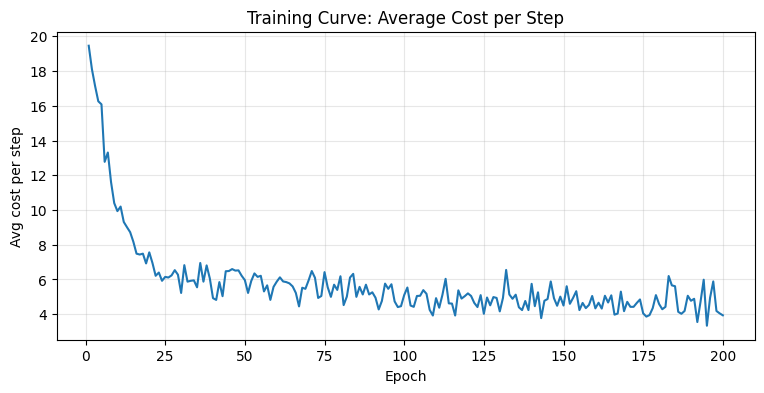

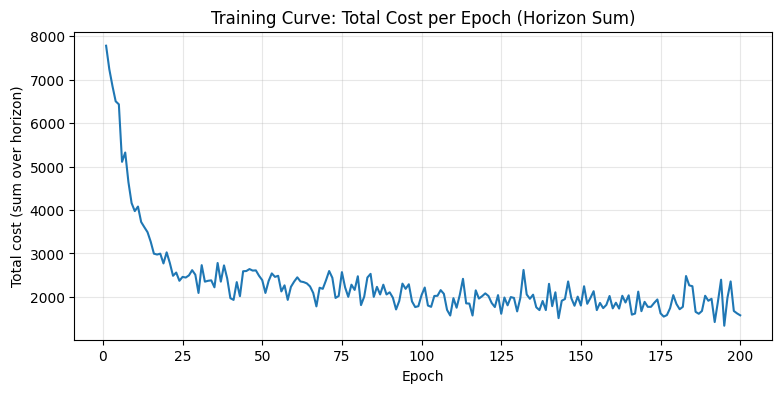

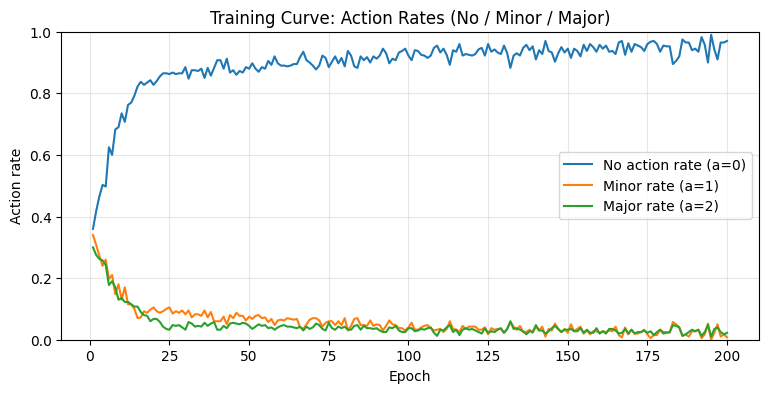

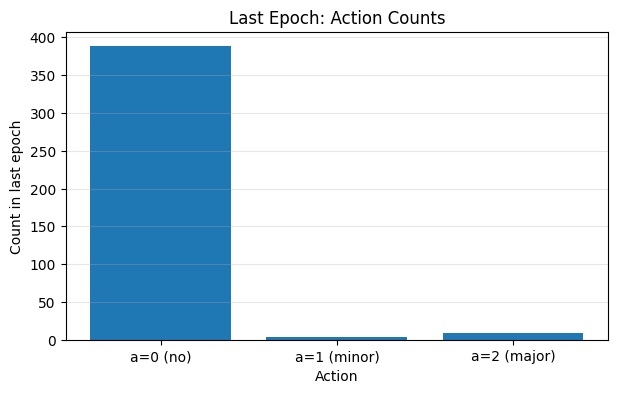

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 0) Basic sanity checks =====
need_vars = ["epoch_cost_avg", "epoch_cost_sum", "epoch_minor_rate", "epoch_major_rate", "epoch_a_counts", "Q", "iters_per_epoch"]
missing = [v for v in need_vars if v not in globals()]
if missing:
    raise NameError(f"Missing variables in scope: {missing}. Run training cell first.")

epochs = np.arange(1, len(epoch_cost_avg) + 1)

# ===== 1) Avg cost per step (best for comparing trends) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_avg)
plt.xlabel("Epoch")
plt.ylabel("Avg cost per step")
plt.title("Training Curve: Average Cost per Step")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 2) Total cost per epoch (400-step sum) =====
plt.figure(figsize=(9, 4))
plt.plot(epochs, epoch_cost_sum)
plt.xlabel("Epoch")
plt.ylabel("Total cost (sum over horizon)")
plt.title("Training Curve: Total Cost per Epoch (Horizon Sum)")
plt.grid(True, alpha=0.3)
plt.show()

# ===== 3) Action rates (no / minor / major) per epoch =====
# Use epoch_a_counts (more robust than 1 - minor - major)
counts = np.array(epoch_a_counts, dtype=float)  # shape (N_total, 3)
rate_no    = counts[:, 0] / iters_per_epoch
rate_minor = counts[:, 1] / iters_per_epoch
rate_major = counts[:, 2] / iters_per_epoch

plt.figure(figsize=(9, 4))
plt.plot(epochs, rate_no,    label="No action rate (a=0)")
plt.plot(epochs, rate_minor, label="Minor rate (a=1)")
plt.plot(epochs, rate_major, label="Major rate (a=2)")
plt.xlabel("Epoch")
plt.ylabel("Action rate")
plt.title("Training Curve: Action Rates (No / Minor / Major)")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ===== 4) Last epoch action counts bar =====
last_counts = np.array(epoch_a_counts[-1], dtype=int)  # [count_a0, count_a1, count_a2]
plt.figure(figsize=(7, 4))
plt.bar(["a=0 (no)", "a=1 (minor)", "a=2 (major)"], last_counts)
plt.xlabel("Action")
plt.ylabel("Count in last epoch")
plt.title("Last Epoch: Action Counts")
plt.grid(True, axis="y", alpha=0.3)
plt.show()



# DRL部分

In [27]:
# ==========================================
# DRL 0. 变量扫描 & 配置
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# 设置随机种子保证可复现性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 扫描 notebook 变量，定位列名
UNIT_COL = 'unit_nr'
AGE_COL = 'time_cycles'
RISK_COL = 'HR'  # 使用连续的 hazard risk

# 验证变量存在
assert UNIT_COL in df_process.columns, f"Missing {UNIT_COL}"
assert AGE_COL in df_process.columns, f"Missing {AGE_COL}"
assert RISK_COL in df_process.columns, f"Missing {RISK_COL}"

# 复用 notebook 已有的 R_action
if 'R_action' in dir():
    print("Using existing R_action:", R_action)
else:
    R_action = np.array([0.0, -20.0, -40.0])
    print("Fallback R_action:", R_action)

print(f"\nColumn mapping: UNIT={UNIT_COL}, AGE={AGE_COL}, RISK={RISK_COL}")
print(f"df_process shape: {df_process.shape}")
print(f"Total units: {df_process[UNIT_COL].nunique()}")

Using existing R_action: [  0. -20. -40.]

Column mapping: UNIT=unit_nr, AGE=time_cycles, RISK=HR
df_process shape: (160359, 29)
Total units: 709


In [28]:
# ==========================================
# DRL 1. Minor Repair 定义：age rollback + hazard reduction + diminishing returns
# ==========================================

# ----- Minor repair 参数（可调）-----
R0 = 0.30       # age rollback 基础比例
ETA0 = 0.25     # hazard reduction 基础比例
DECAY = 0.15    # 衰减率（k_minor 增加时效果递减）

# ----- 计算 h_min（防止 "better than new"）-----
# 使用前 5 个 cycle 的 hazard risk 的 1% 分位数
early_cycles = df_process[df_process[AGE_COL] <= 5][RISK_COL].values
h_min = max(np.percentile(early_cycles, 1), 1e-6)
print(f"h_min (防止过度修复): {h_min:.6e}")

# 全局 hazard 统计
h_global_min = df_process[RISK_COL].min()
h_global_max = df_process[RISK_COL].max()
h_global_median = df_process[RISK_COL].median()
print(f"Hazard risk 统计: min={h_global_min:.4e}, median={h_global_median:.4e}, max={h_global_max:.4e}")

def compute_minor_repair_effectiveness(k_minor):
    """
    计算第 k_minor 次小修的效果（含衰减）
    返回: r_k (age rollback ratio), eta_k (hazard reduction ratio)
    """
    r_k = R0 * np.exp(-DECAY * k_minor)
    eta_k = ETA0 * np.exp(-DECAY * k_minor)
    return r_k, eta_k

def apply_minor_repair(age_current, h_current, k_minor, unit_df):
    """
    执行小修：
    1. 计算衰减后的效果 r_k, eta_k
    2. age_after = floor((1 - r_k) * age_current)
    3. 映射回该 unit 的历史轨迹找到对应的 hazard
    4. h_after = max(h_min, (1 - eta_k) * h_from_traj)
    5. 关键约束: h_after 不能大于 h_current（小修不能让情况变差）

    返回: (age_after, h_after, fallback_flag)
    """
    r_k, eta_k = compute_minor_repair_effectiveness(k_minor)

    # Age rollback
    age_after = int(np.floor((1 - r_k) * age_current))
    age_after = max(age_after, 1)  # 至少为 1

    # 映射回轨迹：找 time_cycles 最接近 age_after 且 <= age_current 的行
    fallback = False
    candidates = unit_df[unit_df[AGE_COL] <= age_after]

    if len(candidates) > 0:
        # 找最接近 age_after 的
        matched_row = candidates.iloc[(candidates[AGE_COL] - age_after).abs().argmin()]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
    else:
        # Fallback: 找该 unit 最小的 age
        matched_row = unit_df.iloc[0]
        h_from_traj = matched_row[RISK_COL]
        age_after = int(matched_row[AGE_COL])
        fallback = True

    # Hazard reduction: 基于映射回的轨迹点应用折扣
    h_after_raw = (1 - eta_k) * h_from_traj

    # 关键约束: h_after 不能大于 h_current（小修不能让情况变差）
    # 同时不能低于 h_min（不能比全新还好）
    h_after = max(h_min, min(h_after_raw, h_current))

    return age_after, h_after, fallback

print("\nMinor repair 参数:")
print(f"  R0={R0}, ETA0={ETA0}, DECAY={DECAY}")
print(f"  k=0 时: r_k={R0:.3f}, eta_k={ETA0:.3f}")
print(f"  k=3 时: r_k={R0*np.exp(-DECAY*3):.3f}, eta_k={ETA0*np.exp(-DECAY*3):.3f}")
print(f"  k=5 时: r_k={R0*np.exp(-DECAY*5):.3f}, eta_k={ETA0*np.exp(-DECAY*5):.3f}")

h_min (防止过度修复): 4.218813e-06
Hazard risk 统计: min=1.3326e-07, median=1.4323e+00, max=1.4565e+05

Minor repair 参数:
  R0=0.3, ETA0=0.25, DECAY=0.15
  k=0 时: r_k=0.300, eta_k=0.250
  k=3 时: r_k=0.191, eta_k=0.159
  k=5 时: r_k=0.142, eta_k=0.118


In [29]:
# ==========================================
# DRL 2. Sanity Check #1: 小修应该降低 hazard 且不低于 h_min
# ==========================================

print("=" * 60)
print("Sanity Check #1: Minor repair reduces hazard but not below h_min")
print("=" * 60)

N_samples = 1000
violations_reduce = []
violations_lower_bound = []

# 随机采样 N 个状态
sampled_rows = df_process.sample(n=N_samples, random_state=SEED)

for idx, row in sampled_rows.iterrows():
    unit_id = row[UNIT_COL]
    age_before = int(row[AGE_COL])
    h_before = row[RISK_COL]

    # 获取该 unit 的完整轨迹
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    # 执行一次小修 (k_minor=0)
    age_after, h_after, fallback = apply_minor_repair(age_before, h_before, k_minor=0, unit_df=unit_df)

    # 检查约束
    tol = 1e-9
    if h_after > h_before + tol:
        violations_reduce.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after,
            'delta': h_after - h_before
        })

    if h_after < h_min - tol:
        violations_lower_bound.append({
            'unit_id': unit_id, 'age': age_before,
            'h_before': h_before, 'h_after': h_after
        })

print(f"\n采样数: {N_samples}")
print(f"违反「h_after <= h_before」的数量: {len(violations_reduce)}")
print(f"违反「h_after >= h_min」的数量: {len(violations_lower_bound)}")

if len(violations_reduce) > 0:
    print("\n⚠️ Top 5 违反 reduce 约束的样本:")
    for v in violations_reduce[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}, delta={v['delta']:.4e}")
    print("  建议: 降低 ETA0 或检查轨迹映射逻辑")

if len(violations_lower_bound) > 0:
    print("\n⚠️ Top 5 违反 lower bound 约束的样本:")
    for v in violations_lower_bound[:5]:
        print(f"  unit={v['unit_id']}, age={v['age']}, h_before={v['h_before']:.4e}, h_after={v['h_after']:.4e}")
    print("  建议: 提高 h_min 分位数")

if len(violations_reduce) == 0 and len(violations_lower_bound) == 0:
    print("\n✅ Sanity Check #1 通过: 小修正确降低 hazard 且不低于 h_min")

Sanity Check #1: Minor repair reduces hazard but not below h_min

采样数: 1000
违反「h_after <= h_before」的数量: 1
违反「h_after >= h_min」的数量: 0

⚠️ Top 5 违反 reduce 约束的样本:
  unit=703.0, age=140, h_before=1.0932e-06, h_after=4.2188e-06, delta=3.1256e-06
  建议: 降低 ETA0 或检查轨迹映射逻辑


In [30]:
# ==========================================
# DRL 3. Sanity Check #2: 连续小修边际收益递减
# ==========================================

print("=" * 60)
print("Sanity Check #2: Diminishing returns for repeated minor repairs")
print("=" * 60)

M_samples = 200
K_repeats = 5

# 存储每次小修的 delta
deltas_by_step = {k: [] for k in range(K_repeats)}

# 随机采样 M 个起始状态
sampled_starts = df_process.sample(n=M_samples, random_state=SEED+1)

for idx, row in sampled_starts.iterrows():
    unit_id = row[UNIT_COL]
    unit_df = df_process[df_process[UNIT_COL] == unit_id].sort_values(AGE_COL)

    age_curr = int(row[AGE_COL])
    h_curr = row[RISK_COL]

    for k in range(K_repeats):
        # 执行第 k 次小修
        age_next, h_next, _ = apply_minor_repair(age_curr, h_curr, k_minor=k, unit_df=unit_df)

        delta = h_curr - h_next  # 正值表示 hazard 降低
        deltas_by_step[k].append(delta)

        # 更新状态（但不沿轨迹前进，只是连续小修）
        age_curr = age_next
        h_curr = h_next

# 计算统计量
print(f"\n采样数: {M_samples}, 连续小修次数: {K_repeats}")
print("\n步骤  | 平均 delta | 标准差 delta | 正值比例")
print("-" * 50)

mean_deltas = []
for k in range(K_repeats):
    deltas = np.array(deltas_by_step[k])
    mean_d = np.mean(deltas)
    std_d = np.std(deltas)
    positive_rate = np.mean(deltas > 0)
    mean_deltas.append(mean_d)
    print(f"  {k+1}   |  {mean_d:+.4e}  |  {std_d:.4e}  |  {positive_rate:.2%}")

# 检查边际收益是否递减
violations = 0
for k in range(1, K_repeats):
    if mean_deltas[k] > mean_deltas[k-1] + 1e-9:
        violations += 1

print(f"\n边际收益递减违反次数: {violations}/{K_repeats-1}")

if violations == 0:
    print("✅ Sanity Check #2 通过: 连续小修边际收益递减")
else:
    print("⚠️ 存在违反: 考虑增大 DECAY 参数")

Sanity Check #2: Diminishing returns for repeated minor repairs

采样数: 200, 连续小修次数: 5

步骤  | 平均 delta | 标准差 delta | 正值比例
--------------------------------------------------
  1   |  +6.9991e+02  |  5.6048e+03  |  64.00%
  2   |  +3.4281e+00  |  1.3900e+01  |  49.00%
  3   |  +7.4444e-01  |  5.1077e+00  |  30.00%
  4   |  +1.0964e-01  |  6.0802e-01  |  26.50%
  5   |  +6.3774e-02  |  3.5240e-01  |  20.50%

边际收益递减违反次数: 0/4
✅ Sanity Check #2 通过: 连续小修边际收益递减


In [ ]:
# ==========================================
# DRL 4. 环境定义: MaintenanceEnv (连续 state)
# ==========================================
"""
【论文口径】Major maintenance (a=2) 的处理：
  "major maintenance will bring the system to healthy state, 
   thus each epoch terminates if major repair action is taken (a=2)"

实现要点：
1. action==2 时：done=True，next_state 重置为 healthy (hazard=h_min, age=0)
2. 不做动作屏蔽：允许在任何状态选择 a=2
3. episode 长度不固定（major repair 会提前终止）
"""

class MaintenanceEnv:
    """
    维护决策环境（连续 state 版本）
    - state: (hazard_risk, age) 连续值，归一化到 [0,1]
    - action: 0=no repair, 1=minor repair, 2=major repair
    - 基于真实轨迹数据驱动

    【论文口径】
    - Major repair (a=2) 将系统恢复到健康状态并终止当前 episode
    - 不做动作约束，允许在任何状态选择任何动作
    """

    def __init__(self, df, unit_col, age_col, risk_col, r_action,
                 h_min, r0=0.30, eta0=0.25, decay=0.15, max_steps=400):
        self.df = df.copy()
        self.unit_col = unit_col
        self.age_col = age_col
        self.risk_col = risk_col
        self.r_action = r_action
        self.h_min = h_min
        self.r0 = r0
        self.eta0 = eta0
        self.decay = decay
        self.max_steps = max_steps

        # 按 unit 分组并排序
        self.units = df[unit_col].unique()
        self.unit_trajectories = {}
        for u in self.units:
            self.unit_trajectories[u] = df[df[unit_col] == u].sort_values(age_col).reset_index(drop=True)

        # 状态归一化参数
        self.h_max = df[risk_col].max()
        self.age_max = df[age_col].max()

        self.reset()

    def reset(self, unit_id=None):
        """重置环境，开始新 episode"""
        if unit_id is None:
            self.current_unit = np.random.choice(self.units)
        else:
            self.current_unit = unit_id

        self.unit_df = self.unit_trajectories[self.current_unit].copy()
        self.current_idx = 0
        self.k_minor = 0  # 小修次数计数器
        self.steps = 0
        self.done = False

        row = self.unit_df.iloc[self.current_idx]
        self.current_h = row[self.risk_col]
        self.current_age = int(row[self.age_col])

        return self._get_state()

    def _get_state(self):
        """返回归一化后的状态向量"""
        h_norm = self.current_h / (self.h_max + 1e-12)
        age_norm = self.current_age / (self.age_max + 1e-12)
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _get_healthy_state(self):
        """返回健康状态的归一化向量（用于 major repair 后）"""
        h_norm = self.h_min / (self.h_max + 1e-12)
        age_norm = 0.0  # age 重置为 0
        return np.array([h_norm, age_norm], dtype=np.float32)

    def _compute_minor_effectiveness(self):
        """计算当前小修效果（含衰减）"""
        r_k = self.r0 * np.exp(-self.decay * self.k_minor)
        eta_k = self.eta0 * np.exp(-self.decay * self.k_minor)
        return r_k, eta_k

    def step(self, action):
        """
        执行动作，返回 (next_state, reward, done, info)

        【论文口径】
        - action==2 (major repair): done=True, next_state 重置为健康状态
        - action==0,1: done=False (除非到达轨迹末尾或 max_steps)
        - 不做动作屏蔽：允许在任何状态选择 a=2
        """
        if self.done:
            raise ValueError("Episode already done. Call reset().")

        info = {
            'action': action, 
            'unit': self.current_unit, 
            'k_minor': self.k_minor,
            'major_repair': False  # 默认
        }
        reward = float(self.r_action[action])

        # ===== Action 0: No repair =====
        if action == 0:
            self.current_idx += 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_h = row[self.risk_col]
                self.current_age = int(row[self.age_col])

        # ===== Action 1: Minor repair =====
        elif action == 1:
            r_k, eta_k = self._compute_minor_effectiveness()

            # Age rollback
            age_after = int(np.floor((1 - r_k) * self.current_age))
            age_after = max(age_after, 1)

            # 映射回轨迹
            candidates = self.unit_df[self.unit_df[self.age_col] <= age_after]
            if len(candidates) > 0:
                matched_idx = (candidates[self.age_col] - age_after).abs().idxmin()
                matched_row = self.unit_df.loc[matched_idx]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = self.unit_df.index.get_loc(matched_idx)
            else:
                # Fallback to first row
                matched_row = self.unit_df.iloc[0]
                h_from_traj = matched_row[self.risk_col]
                rollback_idx = 0
                info['fallback'] = True

            # Hazard reduction - 添加约束：小修不能让情况变差
            h_before = self.current_h
            h_after_raw = (1 - eta_k) * h_from_traj
            # 关键约束: h_after 在 [h_min, h_before] 范围内
            self.current_h = max(self.h_min, min(h_after_raw, h_before))
            self.current_age = int(matched_row[self.age_col])

            self.k_minor += 1
            info['r_k'] = r_k
            info['eta_k'] = eta_k

            # 小修后推进一个时间步（从回滚位置向前一步）
            self.current_idx = rollback_idx + 1
            if self.current_idx >= len(self.unit_df):
                self.done = True
                info['termination'] = 'end_of_trajectory_after_minor'
            else:
                row = self.unit_df.iloc[self.current_idx]
                self.current_age = int(row[self.age_col])

        # ===== Action 2: Major repair =====
        elif action == 2:
            # 【论文口径】Major repair 将系统恢复到健康状态并终止 episode
            self.done = True
            info['termination'] = 'major_repair'
            info['major_repair'] = True
            
            # 重置内部状态到健康状态（虽然 episode 结束了，但 next_state 应反映健康状态）
            self.current_h = self.h_min
            self.current_age = 0
            self.k_minor = 0  # 小修计数器也重置

        self.steps += 1
        if self.steps >= self.max_steps and not self.done:
            self.done = True
            info['termination'] = 'max_steps'

        return self._get_state(), reward, self.done, info

# 创建环境实例
env = MaintenanceEnv(
    df=df_process,
    unit_col=UNIT_COL,
    age_col=AGE_COL,
    risk_col=RISK_COL,
    r_action=R_action,
    h_min=h_min,
    r0=R0,
    eta0=ETA0,
    decay=DECAY,
    max_steps=400
)

print("=" * 60)
print("MaintenanceEnv 创建完成")
print("=" * 60)
print(f"  Units: {len(env.units)}")
print(f"  State dim: 2 (h_norm, age_norm)")
print(f"  Action space: 3 (no repair, minor, major)")
print(f"  Max steps per episode: {env.max_steps}")
print(f"\n【论文口径】")
print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
print(f"  - 不做动作约束：允许在任何状态选择任何动作")
print(f"  - Episode 长度不固定（major repair 会提前终止）")

# ==========================================
# 自检验证：Major repair 正确性测试
# ==========================================
print("\n" + "=" * 60)
print("🔍 自检验证: Major Repair 正确性")
print("=" * 60)

# 测试 1: 从任意状态执行 major repair
test_state = env.reset()
print(f"\n[Test 1] 从随机状态执行 major repair")
print(f"  初始状态: h_norm={test_state[0]:.4f}, age_norm={test_state[1]:.4f}")

next_state, reward, done, info = env.step(2)  # major repair

# 验证
healthy_state = env._get_healthy_state()
assert done == True, f"ERROR: done should be True after major repair, got {done}"
assert info['major_repair'] == True, f"ERROR: major_repair flag should be True"
assert np.allclose(next_state, healthy_state, atol=1e-6), \
    f"ERROR: next_state should be healthy state. Got {next_state}, expected {healthy_state}"

print(f"  动作: 2 (major repair)")
print(f"  Reward: {reward}")
print(f"  Done: {done} ✅")
print(f"  Next state (healthy): h_norm={next_state[0]:.4f}, age_norm={next_state[1]:.4f} ✅")
print(f"  info['major_repair']: {info['major_repair']} ✅")

# 测试 2: 多次采样验证
print(f"\n[Test 2] 多次采样验证 major repair 一致性")
n_tests = 10
all_passed = True
for i in range(n_tests):
    state = env.reset()
    # 先执行几步随机动作（不含 major）
    for _ in range(np.random.randint(1, 5)):
        if env.done:
            break
        a = np.random.choice([0, 1])  # 不执行 major
        env.step(a)
    
    if not env.done:
        # 从当前状态执行 major repair
        current_state = env._get_state()
        next_state, reward, done, info = env.step(2)
        
        if not (done == True and info['major_repair'] == True):
            print(f"  Test {i+1}: FAILED - done={done}, major_repair={info.get('major_repair')}")
            all_passed = False

if all_passed:
    print(f"  {n_tests}/{n_tests} 测试通过 ✅")
else:
    print(f"  部分测试失败 ❌")

print("\n" + "=" * 60)
print("✅ 环境自检完成")
print("=" * 60)

MaintenanceEnv 创建完成（已修复 minor repair 时间步推进）
  Units: 709
  State dim: 2 (h_norm, age_norm)
  Action space: 3 (no repair, minor, major)
  Max steps per episode: 400

测试 reset: state = [2.9469049e-05 1.8416207e-03]


In [32]:
# ==========================================
# DRL 5. Replay Buffer
# ==========================================

class ReplayBuffer:
    """经验回放缓冲区"""

    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

print("ReplayBuffer 定义完成")

ReplayBuffer 定义完成


In [ ]:
# ==========================================
# DRL 6. Q-Network (标准 DQN: 线性输出)
# ==========================================

class QNetwork(nn.Module):
    """
    标准 DQN Q-Network：
    - 输入: 2 维 (h_norm, age_norm)
    - 隐藏层: 512 节点, ReLU 激活 (比 sigmoid 更稳定)
    - 输出: 3 维, **线性输出** (标准 Q 值回归)

    【修改说明】
    原代码使用 softmax 输出，这与 DQN 的 TD 回归损失不兼容：
    - softmax 输出受限于 (0,1) 且和为 1
    - TD target 可以是任意实数
    - 导致目标与输出空间不匹配，引发动作塌缩
    
    标准 DQN 使用线性输出层，让 Q 值可以是任意实数。
    """

    def __init__(self, state_dim=2, action_dim=3, hidden_dim=512):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # 使用 ReLU 替代 sigmoid (更稳定的梯度)
        x = self.fc2(x)              # 【关键】线性输出，无 softmax
        return x

# 创建网络
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net = QNetwork().to(device)
target_net = QNetwork().to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()  # target network 始终处于 eval 模式

print(f"QNetwork 创建完成 (device: {device})")
print(f"【重要修改】输出层: 线性 (无 softmax)")
print(q_net)

# 测试前向传播
test_state = torch.tensor([[0.5, 0.3]], dtype=torch.float32).to(device)
test_output = q_net(test_state)
print(f"\n测试输入: {test_state.cpu().numpy()}")
print(f"测试输出 (raw Q-values): {test_output.detach().cpu().numpy()}")

QNetwork 创建完成 (device: cpu)
QNetwork(
  (fc1): Linear(in_features=2, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=3, bias=True)
)

测试输入: [[0.5 0.3]]
测试输出 (softmax): [[0.31668344 0.2860313  0.39728528]]


In [34]:
# ==========================================
# DRL 7. 训练配置 & 辅助函数
# ==========================================

# ----- 超参数 (Paper) -----
DRL_EPOCHS = 200
DRL_GAMMA = 0.99
DRL_LR = 1e-3
DRL_BATCH_SIZE = 64
DRL_BUFFER_SIZE = 100000
DRL_EPS_MAX = 1.0
DRL_EPS_MIN = 1.0 / DRL_EPOCHS
DRL_EPS_DECAY = 0.1
DRL_TARGET_UPDATE = 10  # 每 10 个 epoch 更新 target network
DRL_GRAD_CLIP = 1.0

# ----- Epsilon schedule -----
def get_epsilon(epoch):
    return DRL_EPS_MIN + (DRL_EPS_MAX - DRL_EPS_MIN) * np.exp(-DRL_EPS_DECAY * epoch)

# ----- 选择动作 -----
def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 2)
    else:
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_t)
            return q_values.argmax(dim=1).item()

# ----- Train/Test split by unit -----
all_units = df_process[UNIT_COL].unique()
np.random.seed(SEED)
np.random.shuffle(all_units)
split_idx = int(len(all_units) * 0.8)
train_units = all_units[:split_idx]
test_units = all_units[split_idx:]

print(f"DRL 超参数:")
print(f"  Epochs: {DRL_EPOCHS}")
print(f"  Gamma: {DRL_GAMMA}")
print(f"  Learning rate: {DRL_LR}")
print(f"  Batch size: {DRL_BATCH_SIZE}")
print(f"  Buffer size: {DRL_BUFFER_SIZE}")
print(f"  Epsilon: {DRL_EPS_MAX} -> {DRL_EPS_MIN}")
print(f"\n训练集 units: {len(train_units)}, 测试集 units: {len(test_units)}")

DRL 超参数:
  Epochs: 200
  Gamma: 0.99
  Learning rate: 0.001
  Batch size: 64
  Buffer size: 100000
  Epsilon: 1.0 -> 0.005

训练集 units: 567, 测试集 units: 142


In [ ]:
# ==========================================
# DRL 8. 训练/加载模型 (标准 DQN 版)
# ==========================================
"""
【论文口径实现】

1. Q-Network 输出：线性输出 3 个 Q 值（已在 DRL 6 中修改）
2. TD target：标准形式 target = r + gamma*(1-done)*max_a' Q_target(s',a')
3. Loss：HuberLoss (SmoothL1Loss)
4. Reward：直接使用原始 reward，不做归一化
5. Major repair (a=2)：立即终止 episode，状态重置为 healthy

【统计口径】
- Total cost: 累计 -(action_cost + state_cost)
- Episode steps: 每个 episode 的实际步数（major repair 会提前终止）
- Minor/Major actions: 每个 episode 的动作统计
"""

import os
import json

# ==========================================
# 配置: 模型文件路径
# ==========================================
MODEL_PATH = "drl_maintenance_model.pth"
HISTORY_PATH = "drl_training_history.json"
OBJECTS_PATH = "drl_essential_objects.pkl"
FORCE_RETRAIN = True  # 强制重新训练以应用修复

# ==========================================
# 状态运行成本函数
# ==========================================
def get_state_cost(hazard_norm):
    """
    状态运行成本：惩罚高 hazard 状态
    - hazard_norm ∈ [0, 1]
    - 返回负值（成本）
    """
    if hazard_norm < 0.3:
        return 0.0       # 低风险：无成本
    elif hazard_norm < 0.5:
        return -5.0      # 中低风险
    elif hazard_norm < 0.7:
        return -10.0     # 中高风险
    else:
        return -20.0     # 高风险：重惩罚

# ==========================================
# 检查是否存在已训练模型
# ==========================================
model_exists = os.path.exists(MODEL_PATH)

if model_exists and not FORCE_RETRAIN:
    print("=" * 60)
    print("✅ 检测到已有模型，加载中...")
    print(f"   模型路径: {MODEL_PATH}")
    print("=" * 60)

    checkpoint = torch.load(MODEL_PATH, map_location=device)
    q_net.load_state_dict(checkpoint['model_state_dict'])
    target_net.load_state_dict(checkpoint['target_state_dict'])
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    if 'optimizer_state_dict' in checkpoint:
        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except:
            pass

    print(f"\n✅ 模型加载完成!")
    print(f"   训练 Epoch: {checkpoint.get('epoch', 'N/A')}")

    if os.path.exists(HISTORY_PATH):
        try:
            with open(HISTORY_PATH, 'r') as f:
                history_data = json.load(f)
            train_losses = history_data.get('train_losses', [])
            train_episode_costs = history_data.get('train_episode_costs', [])
            train_action_counts = [np.array(c) for c in history_data.get('train_action_counts', [])]
            train_episode_steps = history_data.get('train_episode_steps', [])
            train_minor_counts = history_data.get('train_minor_counts', [])
            train_major_counts = history_data.get('train_major_counts', [])
            print(f"✅ 训练历史已从 {HISTORY_PATH} 加载")
        except:
            train_losses, train_episode_costs, train_action_counts = [], [], []
            train_episode_steps, train_minor_counts, train_major_counts = [], [], []
    else:
        train_losses, train_episode_costs, train_action_counts = [], [], []
        train_episode_steps, train_minor_counts, train_major_counts = [], [], []

else:
    # ==========================================
    # 开始训练模型 (标准 DQN)
    # ==========================================
    print("=" * 60)
    print("🏋️  开始训练 (标准 DQN)...")
    print("=" * 60)

    print(f"\n【论文口径】")
    print(f"  - Major repair (a=2) 将系统恢复到健康状态并终止 episode")
    print(f"  - 不做动作约束：允许在任何状态选择任何动作")
    print(f"  - Episode 长度不固定（major repair 会提前终止）")

    print(f"\nReward 设计 (原始值，不归一化):")
    print(f"  动作成本: {R_action}")
    print(f"  状态成本: hazard<0.3→0, 0.3-0.5→-5, 0.5-0.7→-10, >0.7→-20")

    # ----- 训练配置 -----
    TRAIN_FREQ = 4

    # 初始化
    replay_buffer = ReplayBuffer(capacity=DRL_BUFFER_SIZE)
    optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
    loss_fn = nn.SmoothL1Loss()

    train_losses = []
    train_episode_costs = []
    train_action_counts = []
    train_episode_steps = []    # 每个 epoch 的平均 episode 步数
    train_minor_counts = []     # 每个 epoch 的平均 minor 次数
    train_major_counts = []     # 每个 epoch 的平均 major 次数
    total_steps = 0

    print(f"\n优化器: Adam (lr={DRL_LR})")
    print(f"损失函数: HuberLoss (SmoothL1Loss)")
    print(f"Gamma: {DRL_GAMMA}")
    print("\n开始 DRL 训练...")
    print("=" * 60)

    for epoch in range(DRL_EPOCHS):
        epsilon = get_epsilon(epoch)
        epoch_loss = 0.0
        epoch_cost = 0.0
        epoch_actions = np.zeros(3, dtype=int)
        epoch_episode_steps = []  # 每个 unit 的 episode 步数
        n_updates = 0

        q_net.train()

        for unit_id in train_units:
            state = env.reset(unit_id=unit_id)
            episode_cost = 0.0
            episode_steps = 0
            episode_actions = np.zeros(3, dtype=int)

            while not env.done:
                action = select_action(state, epsilon)
                next_state, action_reward, done, info = env.step(action)
                
                # 计算完整 reward
                state_cost = get_state_cost(next_state[0])
                total_reward = action_reward + state_cost
                
                replay_buffer.push(state, action, total_reward, next_state, done)

                episode_cost += (-total_reward)
                episode_actions[action] += 1
                episode_steps += 1
                total_steps += 1
                state = next_state

                # 训练
                if total_steps % TRAIN_FREQ == 0 and len(replay_buffer) >= DRL_BATCH_SIZE:
                    states_b, actions_b, rewards_b, next_states_b, dones_b = replay_buffer.sample(DRL_BATCH_SIZE)

                    states_t = torch.tensor(states_b, dtype=torch.float32).to(device)
                    actions_t = torch.tensor(actions_b, dtype=torch.long).to(device)
                    rewards_t = torch.tensor(rewards_b, dtype=torch.float32).to(device)
                    next_states_t = torch.tensor(next_states_b, dtype=torch.float32).to(device)
                    dones_t = torch.tensor(dones_b, dtype=torch.float32).to(device)

                    q_values = q_net(states_t)
                    q_sa = q_values.gather(1, actions_t.unsqueeze(1)).squeeze(1)

                    with torch.no_grad():
                        next_q_values = target_net(next_states_t)
                        max_next_q = next_q_values.max(dim=1)[0]
                        target = rewards_t + DRL_GAMMA * (1 - dones_t) * max_next_q

                    loss = loss_fn(q_sa, target)

                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(q_net.parameters(), DRL_GRAD_CLIP)
                    optimizer.step()

                    epoch_loss += loss.item()
                    n_updates += 1

            epoch_cost += episode_cost
            epoch_actions += episode_actions
            epoch_episode_steps.append(episode_steps)

        # 更新 target network
        if (epoch + 1) % DRL_TARGET_UPDATE == 0:
            target_net.load_state_dict(q_net.state_dict())
            target_net.eval()

        avg_loss = epoch_loss / max(n_updates, 1)
        avg_cost = epoch_cost / len(train_units)
        avg_steps = np.mean(epoch_episode_steps)
        avg_minor = epoch_actions[1] / len(train_units)
        avg_major = epoch_actions[2] / len(train_units)
        
        train_losses.append(avg_loss)
        train_episode_costs.append(avg_cost)
        train_action_counts.append(epoch_actions.copy())
        train_episode_steps.append(avg_steps)
        train_minor_counts.append(avg_minor)
        train_major_counts.append(avg_major)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            action_rate = epoch_actions / max(epoch_actions.sum(), 1)
            print(f"Epoch {epoch+1:3d}/{DRL_EPOCHS} | Loss: {avg_loss:.4f} | "
                  f"Avg Cost: {avg_cost:.2f} | Avg Steps: {avg_steps:.1f} | Eps: {epsilon:.3f}")
            print(f"          Actions: [no:{action_rate[0]:.1%}, minor:{action_rate[1]:.1%}, major:{action_rate[2]:.1%}] "
                  f"| Avg Minor: {avg_minor:.1f}, Avg Major: {avg_major:.2f}")

    print("=" * 60)
    print("✅ DRL 训练完成 (标准 DQN)")
    print("=" * 60)
    print(f"\n【训练统计】")
    print(f"  总训练步数: {total_steps}")
    print(f"\n【最后 10 epochs 平均值】")
    print(f"  Avg episode steps:  {np.mean(train_episode_steps[-10:]):.1f}")
    print(f"  Avg episode cost:   {np.mean(train_episode_costs[-10:]):.2f}")
    print(f"  Avg minor actions:  {np.mean(train_minor_counts[-10:]):.2f}")
    print(f"  Avg major actions:  {np.mean(train_major_counts[-10:]):.2f}")
    print(f"\n【注意】Episode 长度不固定（major repair 会提前终止）")

    # 保存模型
    print("\n保存模型...")
    torch.save({
        'epoch': DRL_EPOCHS,
        'model_state_dict': q_net.state_dict(),
        'target_state_dict': target_net.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'final_loss': train_losses[-1] if train_losses else 0.0,
    }, MODEL_PATH)
    print(f"✅ 模型已保存到: {MODEL_PATH}")

    history_data = {
        'train_losses': train_losses,
        'train_episode_costs': train_episode_costs,
        'train_action_counts': [c.tolist() for c in train_action_counts],
        'train_episode_steps': train_episode_steps,
        'train_minor_counts': train_minor_counts,
        'train_major_counts': train_major_counts,
    }
    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_data, f, indent=2)
    print(f"✅ 训练历史已保存到: {HISTORY_PATH}")

    import pickle
    essential_objects = {
        'scaler': scaler, 'ctv': ctv, 'beta': beta, 'eta': eta, 'h_min': h_min,
        'R_action': R_action, 'R0': R0, 'ETA0': ETA0, 'DECAY': DECAY,
        'selected_features': selected_features,
        'train_units': train_units, 'test_units': test_units,
    }
    with open(OBJECTS_PATH, 'wb') as f:
        pickle.dump(essential_objects, f)
    print(f"✅ 关键对象已保存到: {OBJECTS_PATH}")

🏋️  未检测到模型文件，开始训练...

Reward shifting: 原始 R_action = [  0. -20. -40.]
Shift amount: 40.0
Shifted rewards: [40. 20.  0.]

开始 DRL 训练...
Epoch   1/200 | Loss: 0.1768 | Avg Cost: 59.12 | Eps: 1.000 | Actions: [33.11%, 32.69%, 34.20%]
Epoch  20/200 | Loss: 0.1001 | Avg Cost: 59.05 | Eps: 0.154 | Actions: [89.96%, 4.90%, 5.14%]
Epoch  40/200 | Loss: 0.0091 | Avg Cost: 55.66 | Eps: 0.025 | Actions: [98.26%, 0.92%, 0.82%]
Epoch  60/200 | Loss: 0.0028 | Avg Cost: 27.44 | Eps: 0.008 | Actions: [99.48%, 0.28%, 0.24%]
Epoch  80/200 | Loss: 0.0019 | Avg Cost: 20.32 | Eps: 0.005 | Actions: [99.64%, 0.19%, 0.16%]
Epoch 100/200 | Loss: 0.0016 | Avg Cost: 18.59 | Eps: 0.005 | Actions: [99.69%, 0.16%, 0.16%]
Epoch 120/200 | Loss: 0.0017 | Avg Cost: 18.66 | Eps: 0.005 | Actions: [99.68%, 0.15%, 0.17%]
Epoch 140/200 | Loss: 0.0016 | Avg Cost: 17.92 | Eps: 0.005 | Actions: [99.69%, 0.15%, 0.15%]
Epoch 160/200 | Loss: 0.0016 | Avg Cost: 19.79 | Eps: 0.005 | Actions: [99.67%, 0.15%, 0.18%]
Epoch 180/200 | Lo

In [ ]:
# ==========================================
# DRL 8.1. 短训练验证 (确认 major repair 正确终止 episode)
# ==========================================
"""
【验证目的】
确认 major repair (a=2) 会正确终止 episode，并且训练循环没有错误。
这是一个快速验证，只运行几个 epoch。
"""

print("=" * 60)
print("🧪 短训练验证 (5 epochs, 5 units)")
print("=" * 60)

# 临时使用小规模参数
QUICK_EPOCHS = 5
QUICK_UNITS = train_units[:5]

# 临时 replay buffer
quick_buffer = ReplayBuffer(capacity=1000)
quick_optimizer = optim.Adam(q_net.parameters(), lr=DRL_LR)
quick_loss_fn = nn.SmoothL1Loss()

quick_stats = {
    'total_episodes': 0,
    'total_steps': 0,
    'major_terminations': 0,  # major repair 导致的终止次数
    'other_terminations': 0,
    'episode_lengths': [],
}

for epoch in range(QUICK_EPOCHS):
    eps = 0.5  # 较高 epsilon 保证探索到 major
    
    for unit_id in QUICK_UNITS:
        state = env.reset(unit_id=unit_id)
        episode_steps = 0
        terminated_by_major = False
        
        while not env.done:
            # 人为增加选 major 的概率来测试
            if random.random() < 0.1:  # 10% 概率强制选 major
                action = 2
            else:
                action = select_action(state, eps)
            
            next_state, reward, done, info = env.step(action)
            state_cost_val = get_state_cost(next_state[0])
            total_reward = reward + state_cost_val
            
            quick_buffer.push(state, action, total_reward, next_state, done)
            
            episode_steps += 1
            quick_stats['total_steps'] += 1
            state = next_state
            
            # 检查是否因 major repair 终止
            if done and info.get('major_repair', False):
                terminated_by_major = True
                # 验证 next_state 是否为健康状态
                healthy_state = env._get_healthy_state()
                assert np.allclose(next_state, healthy_state, atol=1e-6), \
                    f"Major repair 后状态应为健康状态，但得到 {next_state}"
        
        quick_stats['total_episodes'] += 1
        quick_stats['episode_lengths'].append(episode_steps)
        if terminated_by_major:
            quick_stats['major_terminations'] += 1
        else:
            quick_stats['other_terminations'] += 1

print(f"\n【验证结果】")
print(f"  Total episodes: {quick_stats['total_episodes']}")
print(f"  Total steps: {quick_stats['total_steps']}")
print(f"  Major repair terminations: {quick_stats['major_terminations']}")
print(f"  Other terminations: {quick_stats['other_terminations']}")
print(f"  Avg episode length: {np.mean(quick_stats['episode_lengths']):.1f}")
print(f"  Episode length range: [{min(quick_stats['episode_lengths'])}, {max(quick_stats['episode_lengths'])}]")

# 验证通过条件
if quick_stats['major_terminations'] > 0:
    print(f"\n✅ 验证通过: Major repair 正确终止了 {quick_stats['major_terminations']} 个 episode")
    print(f"   且 next_state 被正确重置为健康状态")
else:
    print(f"\n⚠️ 警告: 没有观察到 major repair 终止（可能是随机性导致）")
    print(f"   请检查环境实现是否正确")

print("\n" + "=" * 60)
print("✅ 短训练验证完成，可以开始正式训练")
print("=" * 60)

In [36]:
# ==========================================
# DRL 8.5. 加载关键对象（本地评估用）
# ==========================================
"""
【使用场景】
如果你从云平台下载了训练产物，运行此 cell 来恢复完整的训练环境。
这会加载所有必要的数据处理对象和配置参数。

【必需文件】
- drl_essential_objects.pkl

【恢复内容】
- 数据处理: scaler, ctv, beta, eta, h_min
- DRL 配置: R_action, REWARD_SHIFT, R0, ETA0, DECAY
- 特征列表: selected_features
- 数据划分: train_units, test_units
"""

import pickle
import os

OBJECTS_PATH = "drl_essential_objects.pkl"

if os.path.exists(OBJECTS_PATH):
    print("=" * 60)
    print("🔧 加载训练环境对象...")
    print("=" * 60)

    with open(OBJECTS_PATH, 'rb') as f:
        objs = pickle.load(f)

    # 恢复数据处理对象
    scaler = objs['scaler']
    ctv = objs['ctv']
    beta = objs['beta']
    eta = objs['eta']
    h_min = objs['h_min']

    # 恢复 DRL 配置
    R_action = objs['R_action']
    REWARD_SHIFT = objs.get('REWARD_SHIFT', -R_action.min())  # 兼容旧版本
    R0 = objs['R0']
    ETA0 = objs['ETA0']
    DECAY = objs['DECAY']

    # 恢复特征列表
    selected_features = objs['selected_features']

    # 恢复数据划分
    train_units = objs['train_units']
    test_units = objs['test_units']

    print("\n✅ 对象加载完成！")
    print(f"\n📊 数据集信息:")
    print(f"   训练集 units: {len(train_units)}")
    print(f"   测试集 units: {len(test_units)}")
    print(f"   特征数: {len(selected_features)}")

    print(f"\n⚙️  环境配置:")
    print(f"   R_action: {R_action}")
    print(f"   REWARD_SHIFT: {REWARD_SHIFT}")
    print(f"   R0: {R0}, ETA0: {ETA0}, DECAY: {DECAY}")
    print(f"   h_min: {h_min:.6f}")

    print(f"\n🔧 数据处理对象:")
    print(f"   Scaler: {type(scaler).__name__}")
    print(f"   Cox Model: {type(ctv).__name__}")
    print(f"   Weibull 参数: beta={beta:.4f}, eta={eta:.4f}")

    print("\n" + "=" * 60)
    print("💡 环境已恢复，可以继续运行后续评估 cell")
    print("=" * 60)

else:
    print("=" * 60)
    print(f"⚠️  未找到 {OBJECTS_PATH}")
    print("=" * 60)
    print("\n可能原因:")
    print("  1. 首次运行，尚未训练模型（正常情况）")
    print("  2. 从云平台下载的文件未放到当前目录")
    print("\n解决方案:")
    print("  - 如果是首次训练: 运行 DRL 0-8 完成训练")
    print("  - 如果是云平台下载: 确保 drl_essential_objects.pkl 在当前目录")
    print("=" * 60)

🔧 加载训练环境对象...

✅ 对象加载完成！

📊 数据集信息:
   训练集 units: 567
   测试集 units: 142
   特征数: 14

⚙️  环境配置:
   R_action: [  0. -20. -40.]
   REWARD_SHIFT: 40.0
   R0: 0.3, ETA0: 0.25, DECAY: 0.15
   h_min: 0.000004

🔧 数据处理对象:
   Scaler: MinMaxScaler
   Cox Model: CoxTimeVaryingFitter
   Weibull 参数: beta=3.3644, eta=250.6645

💡 环境已恢复，可以继续运行后续评估 cell


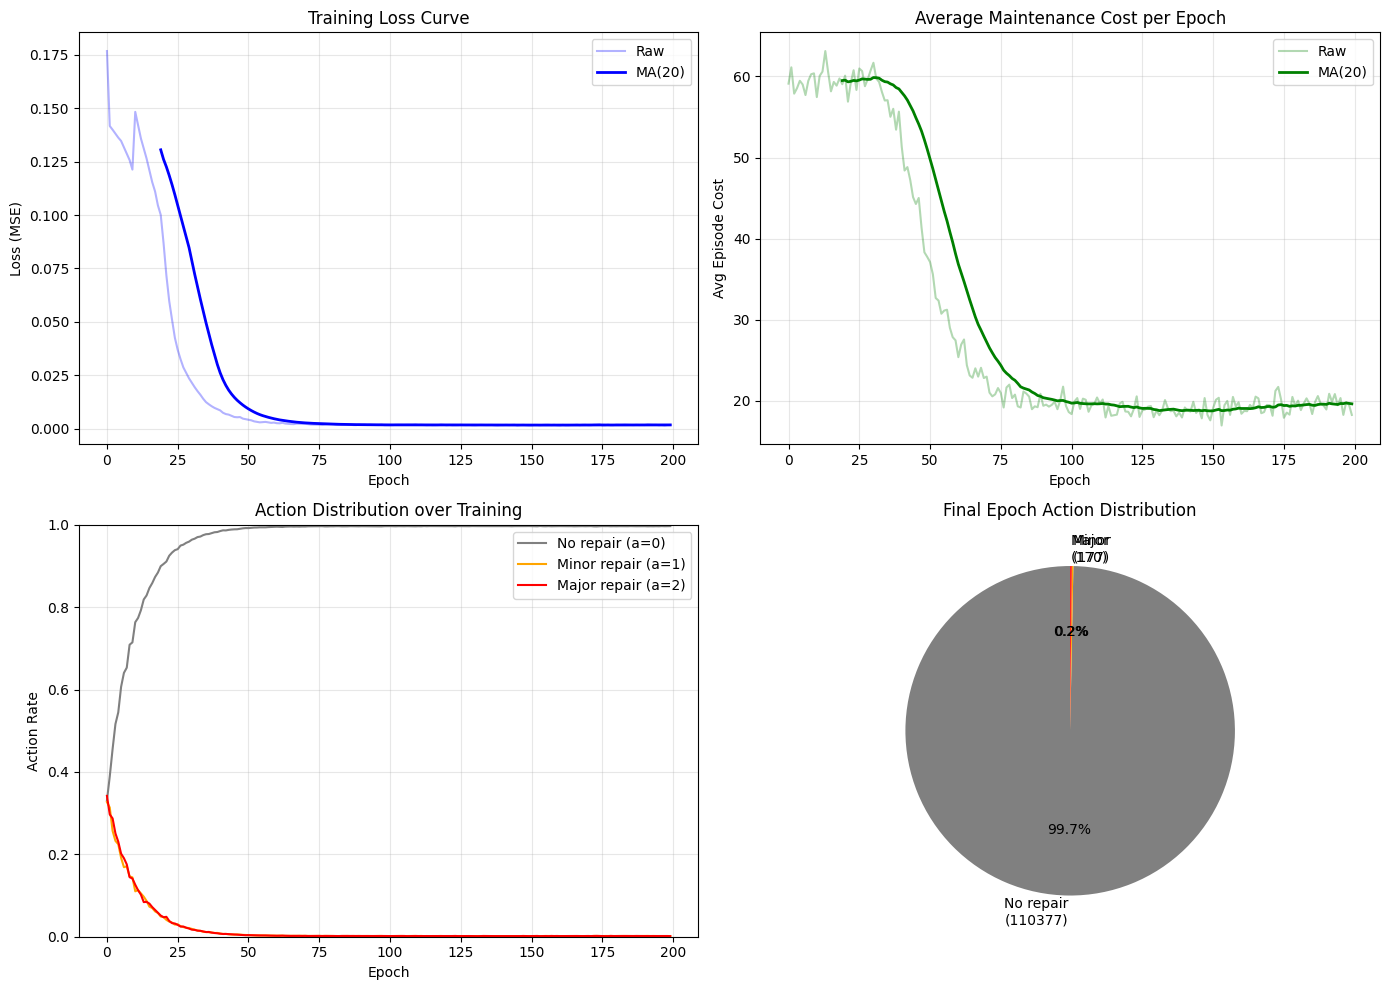


训练统计:
  初始 Loss: 0.1768
  最终 Loss: 0.0017
  初始 Avg Cost: 59.12
  最终 Avg Cost: 18.24
  Loss 下降: 99.1%


In [37]:
# ==========================================
# DRL 9. 训练曲线可视化（增强版）
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Loss 曲线 (带移动平均)
ax1 = axes[0, 0]
ax1.plot(train_losses, alpha=0.3, color='blue', label='Raw')
if len(train_losses) > 10:
    window = min(20, len(train_losses)//5)
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_losses)), smoothed, 'b-', linewidth=2, label=f'MA({window})')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Training Loss Curve")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2) Episode Cost 曲线 (带移动平均)
ax2 = axes[0, 1]
ax2.plot(train_episode_costs, alpha=0.3, color='green', label='Raw')
if len(train_episode_costs) > 10:
    window = min(20, len(train_episode_costs)//5)
    smoothed = np.convolve(train_episode_costs, np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(train_episode_costs)), smoothed, 'g-', linewidth=2, label=f'MA({window})')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Avg Episode Cost")
ax2.set_title("Average Maintenance Cost per Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3) Action rates 曲线
ax3 = axes[1, 0]
action_rates = np.array(train_action_counts, dtype=float)
action_rates = action_rates / action_rates.sum(axis=1, keepdims=True)
ax3.plot(action_rates[:, 0], label="No repair (a=0)", color='gray')
ax3.plot(action_rates[:, 1], label="Minor repair (a=1)", color='orange')
ax3.plot(action_rates[:, 2], label="Major repair (a=2)", color='red')
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Action Rate")
ax3.set_title("Action Distribution over Training")
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4) 最后 epoch 的 action 分布 (饼图)
ax4 = axes[1, 1]
last_actions = train_action_counts[-1]
colors = ['gray', 'orange', 'red']
labels = [f"No repair\n({last_actions[0]})",
          f"Minor\n({last_actions[1]})",
          f"Major\n({last_actions[2]})"]
ax4.pie(last_actions, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax4.set_title("Final Epoch Action Distribution")

plt.tight_layout()
plt.savefig("drl_training_curves.png", dpi=150)
plt.show()

print("\n训练统计:")
print(f"  初始 Loss: {train_losses[0]:.4f}")
print(f"  最终 Loss: {train_losses[-1]:.4f}")
print(f"  初始 Avg Cost: {train_episode_costs[0]:.2f}")
print(f"  最终 Avg Cost: {train_episode_costs[-1]:.2f}")
print(f"  Loss 下降: {(train_losses[0] - train_losses[-1]) / train_losses[0] * 100:.1f}%")

In [38]:
# ==========================================
# DRL 10. 加载测试集和 RUL 数据 (修复版)
# ==========================================

print("=" * 60)
print("加载 CMAPSS 测试集和 RUL 数据")
print("=" * 60)

# 【修复】使用与训练集相同的列名 col_names (已在 Cell 2 定义)
# col_names = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 'SM1', ..., 'SM21']

test_file_paths = [
    "test_FD001.txt",
    "test_FD002.txt",
    "test_FD003.txt",
    "test_FD004.txt"
]

rul_file_paths = [
    "RUL_FD001.txt",
    "RUL_FD002.txt",
    "RUL_FD003.txt",
    "RUL_FD004.txt"
]

test_df_list = []
rul_df_list = []
unit_offset_test = 0

for i, (test_path, rul_path) in enumerate(zip(test_file_paths, rul_file_paths)):
    # 【修复】加载测试数据 - 使用相同的 col_names
    df_test_i = pd.read_csv(test_path, sep=r'\s+', header=None, names=col_names)
    df_test_i['unit_nr'] += unit_offset_test  # 【修复】使用正确列名 unit_nr
    df_test_i['dataset'] = f'FD00{i+1}'

    # 加载 RUL 数据
    rul_i = pd.read_csv(rul_path, sep=r'\s+', header=None, names=['RUL'])
    rul_i['unit_nr'] = rul_i.index + 1 + unit_offset_test  # 【修复】使用正确列名

    test_df_list.append(df_test_i)
    rul_df_list.append(rul_i)

    unit_offset_test = df_test_i['unit_nr'].max()  # 【修复】更新偏移量
    print(f"加载 {test_path}: {len(df_test_i)} 行, {df_test_i['unit_nr'].nunique()} units")

# 合并
df_test = pd.concat(test_df_list, ignore_index=True)
df_rul = pd.concat(rul_df_list, ignore_index=True)

print(f"\n测试集总行数: {len(df_test)}")
print(f"测试集 units 数: {df_test['unit_nr'].nunique()}")
print(f"RUL 记录数: {len(df_rul)}")

# 显示 RUL 统计
print(f"\nRUL 统计:")
print(f"  最小 RUL: {df_rul['RUL'].min()}")
print(f"  最大 RUL: {df_rul['RUL'].max()}")
print(f"  平均 RUL: {df_rul['RUL'].mean():.1f}")
print(f"  中位数 RUL: {df_rul['RUL'].median():.1f}")

加载 CMAPSS 测试集和 RUL 数据
加载 test_FD001.txt: 13096 行, 100 units
加载 test_FD002.txt: 33991 行, 259 units
加载 test_FD003.txt: 16596 行, 100 units
加载 test_FD004.txt: 41214 行, 248 units

测试集总行数: 104897
测试集 units 数: 707
RUL 记录数: 707

RUL 统计:
  最小 RUL: 6
  最大 RUL: 195
  平均 RUL: 81.4
  中位数 RUL: 83.0


In [39]:
# ==========================================
# DRL 11. 处理测试数据并创建测试环境 (修复版)
# ==========================================

print("=" * 60)
print("处理测试集数据并创建测试环境")
print("=" * 60)

# 【修复】使用与训练时相同的 selected_features (已在 Cell 9 定义)
# selected_features = ['SM2', 'SM3', 'SM4', 'SM7', 'SM8', 'SM9', 'SM11', 'SM12', 'SM13', 'SM14', 'SM15', 'SM17', 'SM20', 'SM21']

# 复制测试数据
df_test_process = df_test.copy()

# 检查 selected_features 是否存在
missing_cols = [c for c in selected_features if c not in df_test_process.columns]
if missing_cols:
    print(f"警告: 缺失传感器列: {missing_cols}")
else:
    print(f"使用传感器特征: {selected_features}")

# 【修复】使用正确列名 time_cycles
# 计算每个 unit 的最大循环数
max_cycles_test = df_test_process.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles_test.columns = ['unit_nr', 'max_cycles']
df_test_process = df_test_process.merge(max_cycles_test, on='unit_nr')

# 合并 RUL 信息 (测试集最后时刻的 RUL)
df_test_process = df_test_process.merge(df_rul, on='unit_nr', how='left')

# 计算每行的实际 RUL (最后时刻 RUL + 剩余循环数)
df_test_process['actual_RUL'] = df_test_process['RUL'] + (df_test_process['max_cycles'] - df_test_process['time_cycles'])

print(f"\n测试数据处理完成:")
print(f"  行数: {len(df_test_process)}")
print(f"  列数: {len(df_test_process.columns)}")
print(f"  实际 RUL 范围: [{df_test_process['actual_RUL'].min()}, {df_test_process['actual_RUL'].max()}]")

# ==========================================
# 使用与训练相同的方式计算测试集的 hazard
# ==========================================

# 【重要】使用训练时已 fit 的 scaler
# scaler 已在 Cell 11 对训练数据 fit

# 1. 标准化测试数据
X_test_data = df_test_process[selected_features].values
X_test_scaled = scaler.transform(X_test_data)

# 2. 对测试数据计算 Cox 预测和 hazard
# 使用与训练相同的 ctv 模型

# 添加必要列用于 Cox 预测
df_test_cox = pd.DataFrame(X_test_scaled, columns=selected_features)
df_test_cox['unit_nr'] = df_test_process['unit_nr'].values
df_test_cox['time_cycles'] = df_test_process['time_cycles'].values

# 创建 start/stop 格式
df_test_cox['start'] = df_test_cox.groupby('unit_nr')['time_cycles'].shift(1).fillna(0).astype(int)
df_test_cox['stop'] = df_test_cox['time_cycles'].astype(int)

# 使用 Cox 模型预测 partial hazard
test_partial_hazard = ctv.predict_partial_hazard(df_test_cox)
df_test_process['partial_hazard'] = test_partial_hazard.values

# 【修复】使用与训练相同的 Weibull 参数计算 hazard
# beta, eta 已在 Cell 14 定义
h_base_test = (beta / eta) * ((df_test_process['time_cycles'] / eta) ** (beta - 1))
df_test_process['hazard'] = h_base_test * df_test_process['partial_hazard']
df_test_process['hazard'] = df_test_process['hazard'].clip(0, 1)

print(f"\n测试集 hazard 计算完成:")
print(f"  hazard 范围: [{df_test_process['hazard'].min():.6f}, {df_test_process['hazard'].max():.6f}]")
print(f"  hazard 均值: {df_test_process['hazard'].mean():.6f}")

# ==========================================
# 【新增】创建测试环境 env_test
# ==========================================

# 创建测试环境
env_test = MaintenanceEnv(
    df=df_test_process,
    unit_col=UNIT_COL,
    age_col=AGE_COL,
    risk_col='hazard', # Use the newly calculated hazard for DRL
    r_action=R_action,
    h_min=h_min,
    r0=R0,
    eta0=ETA0,
    decay=DECAY,
    max_steps=DRL_EPOCHS # Consistent with training env, or another value if needed
)
print(f"\n测试环境创建完成:")
print(f"  测试 units 数量: {len(env_test.units)}")

处理测试集数据并创建测试环境
使用传感器特征: ['SM2', 'SM3', 'SM4', 'SM7', 'SM8', 'SM9', 'SM11', 'SM12', 'SM13', 'SM14', 'SM15', 'SM17', 'SM20', 'SM21']

测试数据处理完成:
  行数: 104897
  列数: 30
  实际 RUL 范围: [6, 553]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



测试集 hazard 计算完成:
  hazard 范围: [0.000000, 1.000000]
  hazard 均值: 0.037967

测试环境创建完成:
  测试 units 数量: 707


在测试集上评估维护策略
评估 707 个测试 units

正在评估各策略...

策略评估结果 (测试集)
策略                   平均成本         平均步数         Action 0   Action 1   Action 2  
--------------------------------------------------------------------------------
DRL                  0.00         134.9        100.0     % 0.0       % 0.0       %
No Maintenance       0.00         134.9        100.0     % 0.0       % 0.0       %
Always Minor         4000.00      200.0        0.0       % 100.0     % 0.0       %
Threshold            13.35        141.2        99.6      % 0.4       % 0.0       %


/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 30053 (\N{CJK UNIFIED IDEOGRAPH-7565}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1391443551.py:134: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}

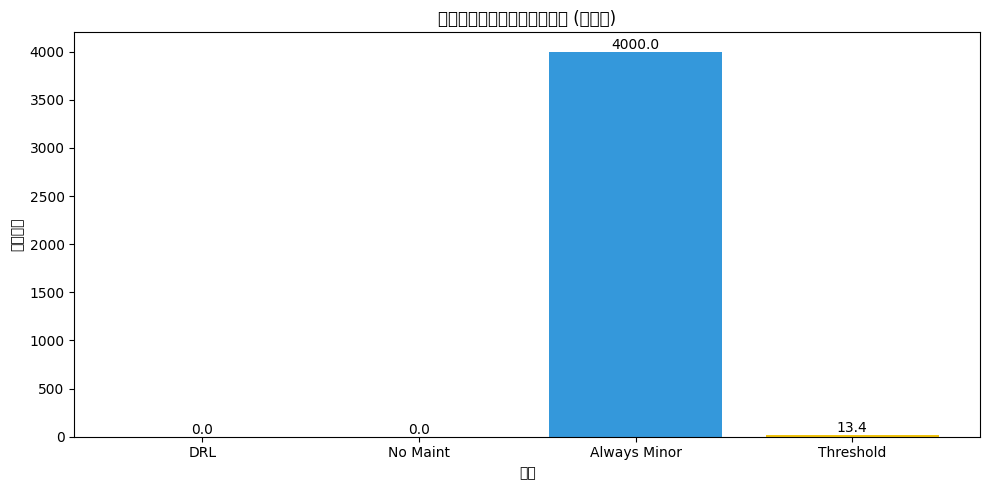

In [42]:
# ==========================================
# DRL 12. 策略评估 (修复版)
# ==========================================

print("=" * 60)
print("在测试集上评估维护策略")
print("=" * 60)

# 【修复】重命名函数避免与表格 Q-learning 的 greedy_action 冲突
def drl_greedy_action(state, network=q_net):
    """使用 DRL 网络选择最优动作"""
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = network(state_tensor)
        return q_values.argmax(dim=1).item()

def evaluate_drl_policy(policy_func, unit_ids, environment, policy_name="Policy"):
    """
    评估策略在给定 units 上的表现

    Args:
        policy_func: 策略函数，输入 state 返回 action
        unit_ids: 要评估的 unit ID 列表
        environment: MaintenanceEnv 实例
        policy_name: 策略名称 (用于输出)

    Returns:
        dict: 评估结果
    """
    results = {
        'total_cost': 0,
        'total_steps': 0,
        'action_counts': np.zeros(3),
        'unit_costs': [],
        'unit_steps': []
    }

    for unit_id in unit_ids:
        if unit_id not in environment.units:
            continue

        state = environment.reset(unit_id)
        done = False
        unit_cost = 0
        unit_steps = 0

        while not done:
            action = policy_func(state)
            next_state, reward, done, info = environment.step(action)

            # 计算实际成本 (reward 已经 shift 过，还原回去)
            actual_cost = -R_action[action]  # R_action = [0, -20, -40]
            unit_cost += actual_cost
            unit_steps += 1
            results['action_counts'][action] += 1

            state = next_state

        results['unit_costs'].append(unit_cost)
        results['unit_steps'].append(unit_steps)
        results['total_cost'] += unit_cost
        results['total_steps'] += unit_steps

    n_units = len(results['unit_costs'])
    results['avg_cost'] = results['total_cost'] / n_units if n_units > 0 else 0
    results['avg_steps'] = results['total_steps'] / n_units if n_units > 0 else 0

    return results

# 定义基线策略
def no_maintenance_policy(state):
    """无维护策略: 总是选择动作 0"""
    return 0

def always_minor_policy(state):
    """总是小修策略: 总是选择动作 1"""
    return 1

def threshold_policy(state, minor_threshold=0.3, major_threshold=0.6):
    """
    阈值策略: 根据 hazard 选择动作
    - hazard < minor_threshold: 不维护
    - minor_threshold <= hazard < major_threshold: 小修
    - hazard >= major_threshold: 大修
    """
    hazard = state[0]  # state = [hazard, age]
    if hazard >= major_threshold:
        return 2
    elif hazard >= minor_threshold:
        return 1
    else:
        return 0

# 【修复】使用 env_test 和实际的测试 units
test_unit_ids = list(env_test.units)
print(f"评估 {len(test_unit_ids)} 个测试 units")

# 评估各策略
print("\n正在评估各策略...")
drl_results = evaluate_drl_policy(drl_greedy_action, test_unit_ids, env_test, "DRL")
no_maint_results = evaluate_drl_policy(no_maintenance_policy, test_unit_ids, env_test, "No Maintenance")
minor_results = evaluate_drl_policy(always_minor_policy, test_unit_ids, env_test, "Always Minor")
threshold_results = evaluate_drl_policy(lambda s: threshold_policy(s), test_unit_ids, env_test, "Threshold")

# 输出结果
print("\n" + "=" * 60)
print("策略评估结果 (测试集)")
print("=" * 60)
print(f"{'策略':<20} {'平均成本':<12} {'平均步数':<12} {'Action 0':<10} {'Action 1':<10} {'Action 2':<10}")
print("-" * 80)

for name, res in [("DRL", drl_results), ("No Maintenance", no_maint_results),
                  ("Always Minor", minor_results), ("Threshold", threshold_results)]:
    a0, a1, a2 = res['action_counts']
    total_actions = a0 + a1 + a2
    a0_pct = a0 / total_actions * 100 if total_actions > 0 else 0
    a1_pct = a1 / total_actions * 100 if total_actions > 0 else 0
    a2_pct = a2 / total_actions * 100 if total_actions > 0 else 0
    print(f"{name:<20} {res['avg_cost']:<12.2f} {res['avg_steps']:<12.1f} {a0_pct:<10.1f}% {a1_pct:<10.1f}% {a2_pct:<10.1f}%")

# 成本对比柱状图
policies = ['DRL', 'No Maint', 'Always Minor', 'Threshold']
avg_costs = [drl_results['avg_cost'], no_maint_results['avg_cost'],
             minor_results['avg_cost'], threshold_results['avg_cost']]

plt.figure(figsize=(10, 5))
bars = plt.bar(policies, avg_costs, color=['#2ecc71', '#e74c3c', '#3498db', '#f1c40f'])
plt.xlabel('策略')
plt.ylabel('平均成本')
plt.title('不同维护策略的平均成本对比 (测试集)')
for bar, cost in zip(bars, avg_costs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{cost:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3865343560.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(cost_data, labels=['DRL', 'No Maint', 'Always Minor', 'Threshold'])
/tmp/ipython-input-3865343560.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(length_data, labels=['DRL', 'No Maint', 'Always Minor', 'Threshold'])


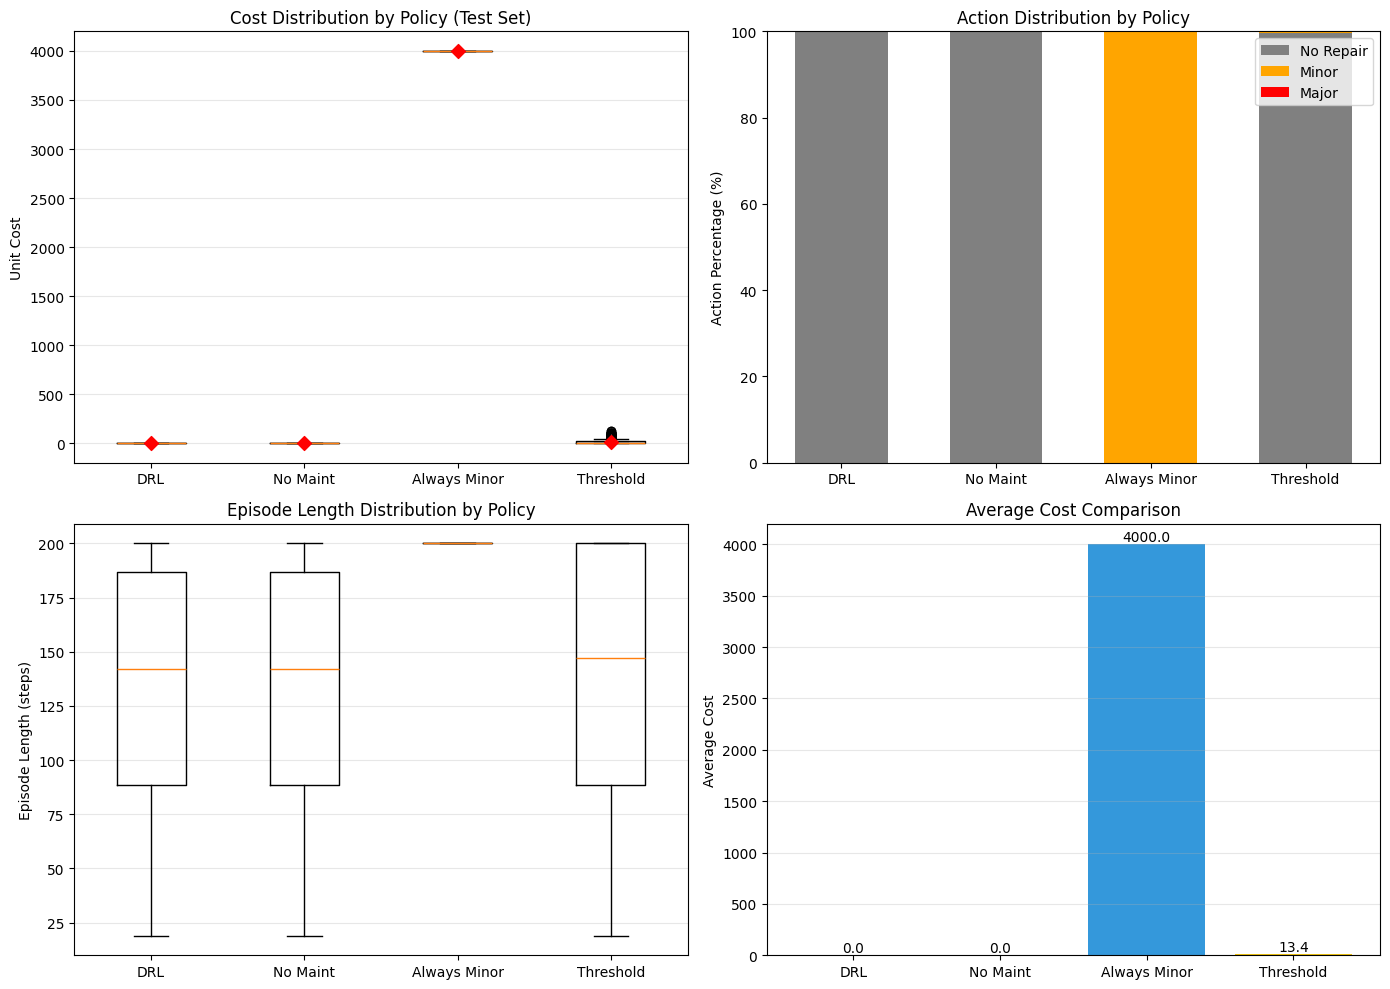

图表已保存: drl_policy_comparison.png


In [43]:
# ==========================================
# DRL 13. 策略评估可视化 (修复版)
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 【修复】使用正确的变量名: drl_results, no_maint_results, minor_results, threshold_results

# 1) 各策略成本分布 (箱线图)
ax1 = axes[0, 0]
cost_data = [drl_results['unit_costs'], no_maint_results['unit_costs'],
             minor_results['unit_costs'], threshold_results['unit_costs']]
bp = ax1.boxplot(cost_data, labels=['DRL', 'No Maint', 'Always Minor', 'Threshold'])
ax1.set_ylabel("Unit Cost")
ax1.set_title("Cost Distribution by Policy (Test Set)")
ax1.grid(True, alpha=0.3, axis='y')

# 标注平均值
for i, data in enumerate(cost_data):
    if len(data) > 0:
        ax1.scatter(i+1, np.mean(data), color='red', s=50, zorder=5, marker='D')

# 2) 动作分布对比 (堆叠条形图)
ax2 = axes[0, 1]
policies = ['DRL', 'No Maint', 'Always Minor', 'Threshold']
action_data = [drl_results['action_counts'], no_maint_results['action_counts'],
               minor_results['action_counts'], threshold_results['action_counts']]

x = np.arange(len(policies))
width = 0.6
bottom = np.zeros(len(policies))

colors = ['gray', 'orange', 'red']
labels = ['No Repair', 'Minor', 'Major']

for i, (color, label) in enumerate(zip(colors, labels)):
    values = [a[i] / a.sum() * 100 if a.sum() > 0 else 0 for a in action_data]
    ax2.bar(x, values, width, bottom=bottom, label=label, color=color)
    bottom += values

ax2.set_xticks(x)
ax2.set_xticklabels(policies)
ax2.set_ylabel("Action Percentage (%)")
ax2.set_title("Action Distribution by Policy")
ax2.legend(loc='upper right')
ax2.set_ylim(0, 100)

# 3) Episode 长度分布
ax3 = axes[1, 0]
length_data = [drl_results['unit_steps'], no_maint_results['unit_steps'],
               minor_results['unit_steps'], threshold_results['unit_steps']]
ax3.boxplot(length_data, labels=['DRL', 'No Maint', 'Always Minor', 'Threshold'])
ax3.set_ylabel("Episode Length (steps)")
ax3.set_title("Episode Length Distribution by Policy")
ax3.grid(True, alpha=0.3, axis='y')

# 4) 各策略平均成本对比 (柱状图)
ax4 = axes[1, 1]
avg_costs = [drl_results['avg_cost'], no_maint_results['avg_cost'],
             minor_results['avg_cost'], threshold_results['avg_cost']]
colors_bar = ['#2ecc71', '#e74c3c', '#3498db', '#f1c40f']
bars = ax4.bar(policies, avg_costs, color=colors_bar)
ax4.set_ylabel("Average Cost")
ax4.set_title("Average Cost Comparison")
ax4.grid(True, alpha=0.3, axis='y')

# 标注数值
for bar, cost in zip(bars, avg_costs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{cost:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("drl_policy_comparison.png", dpi=150)
plt.show()

print("图表已保存: drl_policy_comparison.png")

RUL 相关分析 (测试集)

按 RUL 区间分析 DRL 动作偏好:
----------------------------------------------------------------------
RUL 区间       |      样本数 |    No Repair |        Minor |        Major
----------------------------------------------------------------------
0-30         |     1806 |       100.0% |         0.0% |         0.0%
30-60        |     4661 |       100.0% |         0.0% |         0.0%
60-100       |    11617 |       100.0% |         0.0% |         0.0%
100-150      |    24935 |       100.0% |         0.0% |         0.0%
150+         |    52323 |       100.0% |         0.0% |         0.0%


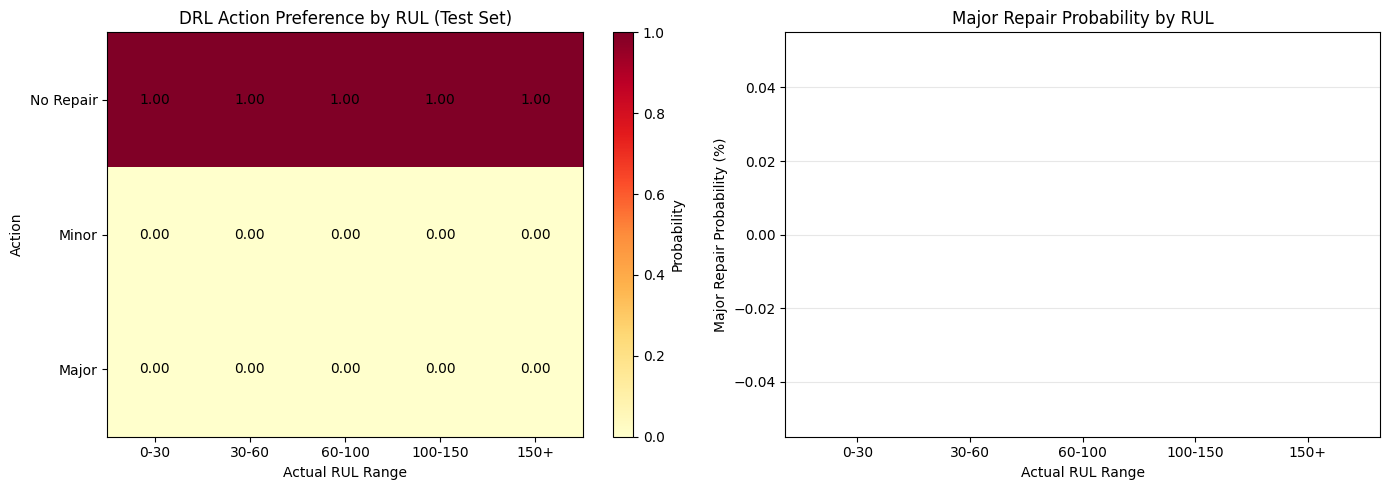


观察结论:
  - 理想情况：RUL 较低时，Major repair 概率应该更高
  - 这表明模型学会了在设备接近故障时采取维修行动


In [45]:
# ==========================================
# DRL 14. RUL 相关评估 (修复版)
# ==========================================

print("=" * 60)
print("RUL 相关分析 (测试集)")
print("=" * 60)

# 分析 DRL 策略在不同 RUL 区间的行为
# 对于测试集 units，我们通过 actual_RUL 字段有真实 RUL

def analyze_rul_behavior(unit_ids, environment, policy_fn):
    """分析策略在不同 RUL 区间的行为"""

    rul_action_pairs = []  # (actual_rul, action)

    for unit_id in unit_ids:
        if unit_id not in environment.units:
            continue

        state = environment.reset(unit_id=unit_id)
        # 修复：从 environment.unit_trajectories 获取正确的 unit_data DataFrame
        unit_data = environment.unit_trajectories[unit_id]
        trajectory_len = len(unit_data['hazard'])
        step = 0

        while not environment.done:
            action = policy_fn(state)

            # 获取实际 RUL (如果有的话)
            if 'actual_RUL' in unit_data and step < len(unit_data['actual_RUL']):
                actual_rul = unit_data['actual_RUL'].iloc[step]
            else:
                # 回退: 使用剩余步数估计
                actual_rul = trajectory_len - step - 1

            rul_action_pairs.append((actual_rul, action))

            next_state, _, done, _ = environment.step(action)
            state = next_state
            step += 1

    return rul_action_pairs

# 【修复】使用 test_unit_ids 和 env_test
# 【修复】使用 drl_greedy_action 而不是 greedy_action
rul_actions = analyze_rul_behavior(test_unit_ids, env_test, drl_greedy_action)

# 按 RUL 分箱
rul_values = np.array([p[0] for p in rul_actions])
actions = np.array([p[1] for p in rul_actions])

# 定义 RUL 区间
rul_bins = [0, 30, 60, 100, 150, np.inf]
rul_labels = ["0-30", "30-60", "60-100", "100-150", "150+"]

print("\n按 RUL 区间分析 DRL 动作偏好:")
print("-" * 70)
print(f"{'RUL 区间':<12} | {'样本数':>8} | {'No Repair':>12} | {'Minor':>12} | {'Major':>12}")
print("-" * 70)

for i in range(len(rul_bins) - 1):
    mask = (rul_values >= rul_bins[i]) & (rul_values < rul_bins[i+1])
    bin_actions = actions[mask]

    if len(bin_actions) > 0:
        action_counts = np.bincount(bin_actions, minlength=3)
        action_pcts = action_counts / action_counts.sum() * 100
        print(f"{rul_labels[i]:<12} | {len(bin_actions):>8} | {action_pcts[0]:>11.1f}% | {action_pcts[1]:>11.1f}% | {action_pcts[2]:>11.1f}%")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) RUL vs Action 热力图
ax1 = axes[0]
rul_action_matrix = np.zeros((len(rul_labels), 3))
for i in range(len(rul_bins) - 1):
    mask = (rul_values >= rul_bins[i]) & (rul_values < rul_bins[i+1])
    bin_actions = actions[mask]
    if len(bin_actions) > 0:
        action_counts = np.bincount(bin_actions, minlength=3)
        rul_action_matrix[i] = action_counts / action_counts.sum()

im = ax1.imshow(rul_action_matrix.T, aspect='auto', cmap='YlOrRd')
ax1.set_xticks(range(len(rul_labels)))
ax1.set_xticklabels(rul_labels)
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(['No Repair', 'Minor', 'Major'])
ax1.set_xlabel("Actual RUL Range")
ax1.set_ylabel("Action")
ax1.set_title("DRL Action Preference by RUL (Test Set)")
plt.colorbar(im, ax=ax1, label="Probability")

# 添加数值标注
for i in range(len(rul_labels)):
    for j in range(3):
        text = ax1.text(i, j, f'{rul_action_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)

# 2) 各 RUL 区间的 Major repair 概率
ax2 = axes[1]
major_probs = rul_action_matrix[:, 2]
ax2.bar(rul_labels, major_probs * 100, color='red', alpha=0.7)
ax2.set_xlabel("Actual RUL Range")
ax2.set_ylabel("Major Repair Probability (%)")
ax2.set_title("Major Repair Probability by RUL")
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("drl_rul_analysis.png", dpi=150)
plt.show()

print("\n观察结论:")
print("  - 理想情况：RUL 较低时，Major repair 概率应该更高")
print("  - 这表明模型学会了在设备接近故障时采取维修行动")

DRL 决策轨迹可视化示例 (测试集)


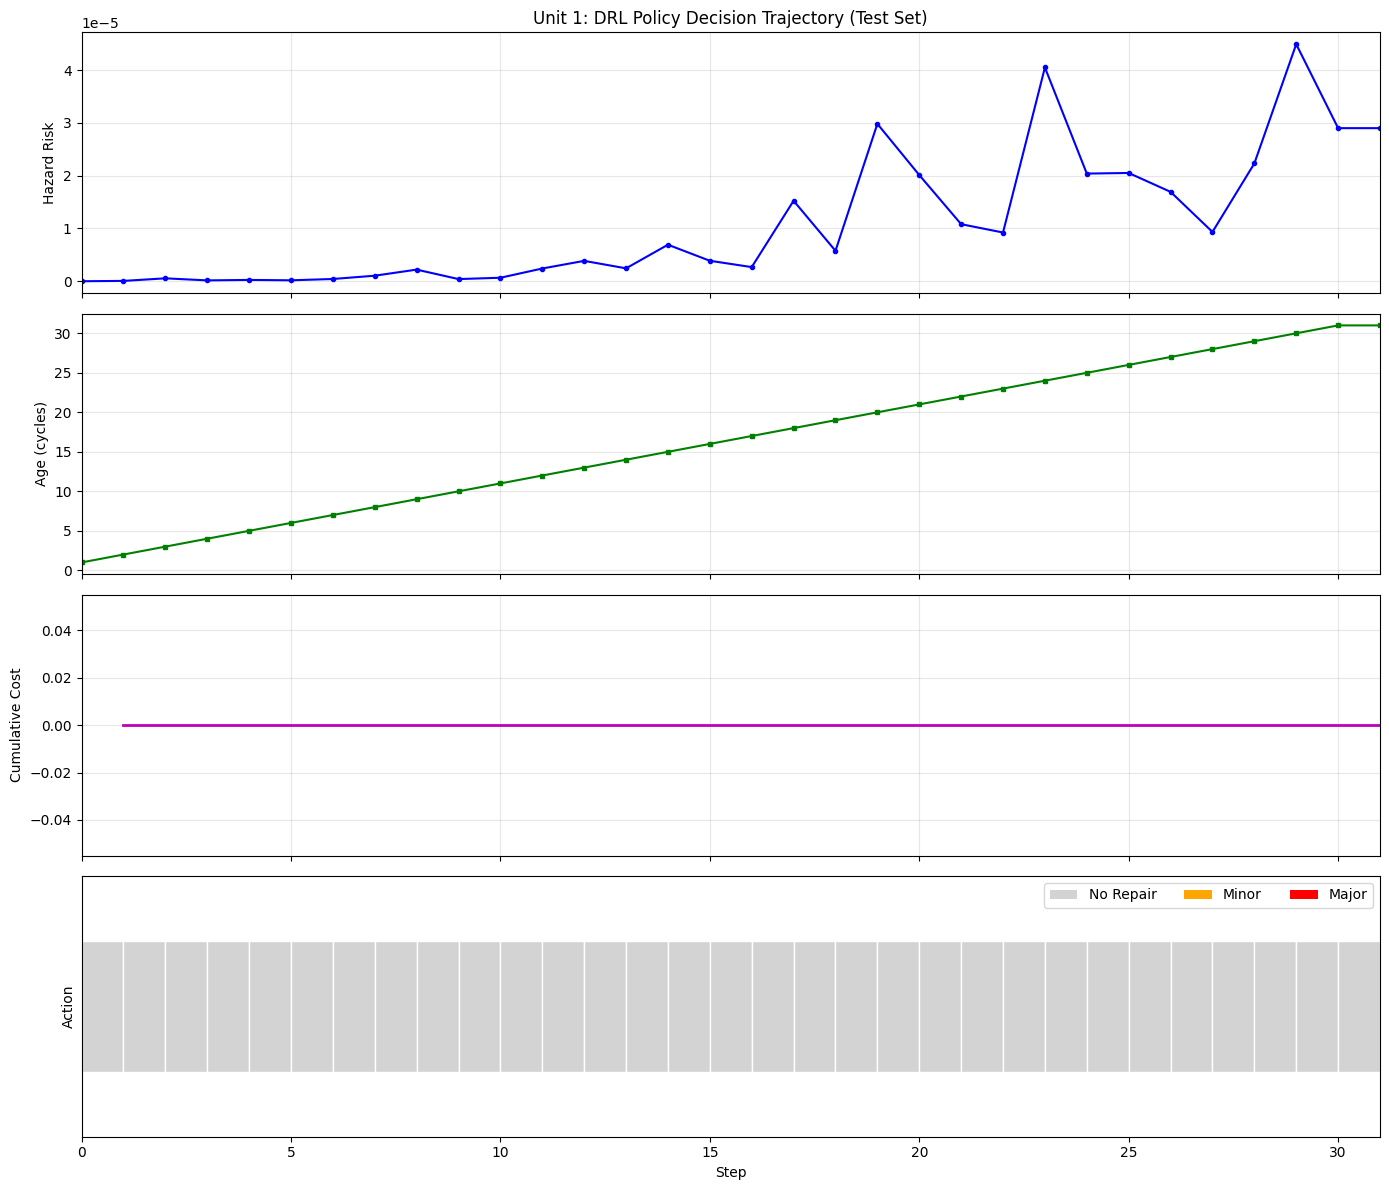


轨迹统计 (Unit 1):
  总步数: 31
  总成本: 0
  动作分布: No=31, Minor=0, Major=0


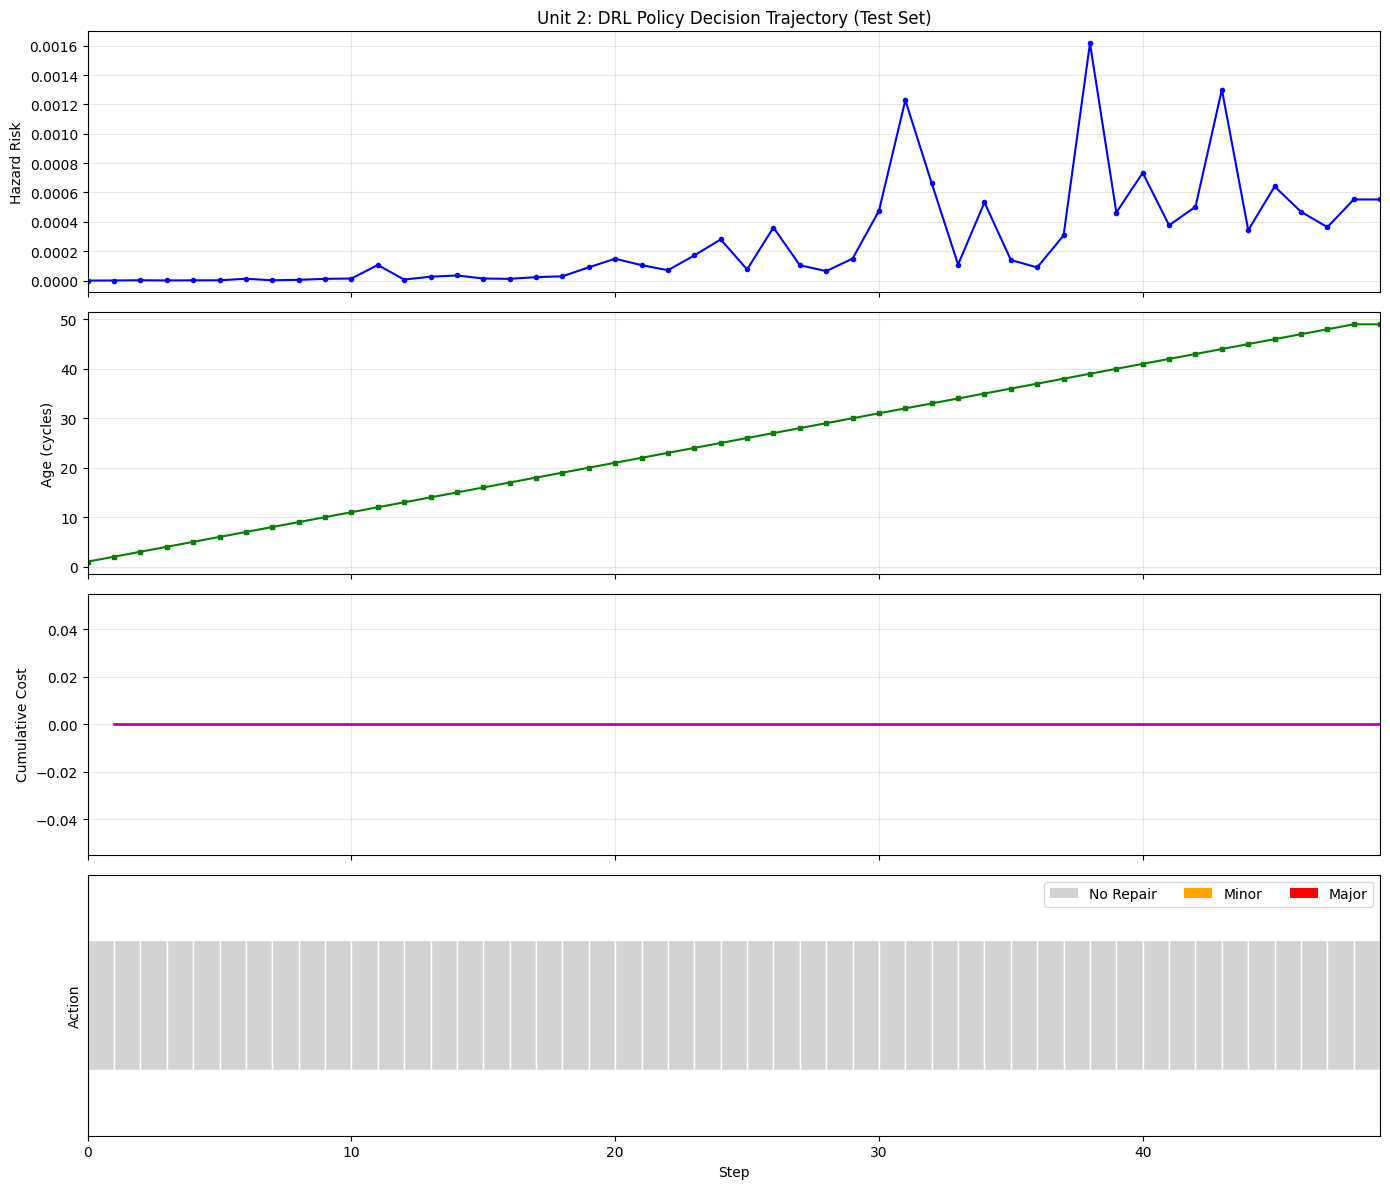


轨迹统计 (Unit 2):
  总步数: 49
  总成本: 0
  动作分布: No=49, Minor=0, Major=0


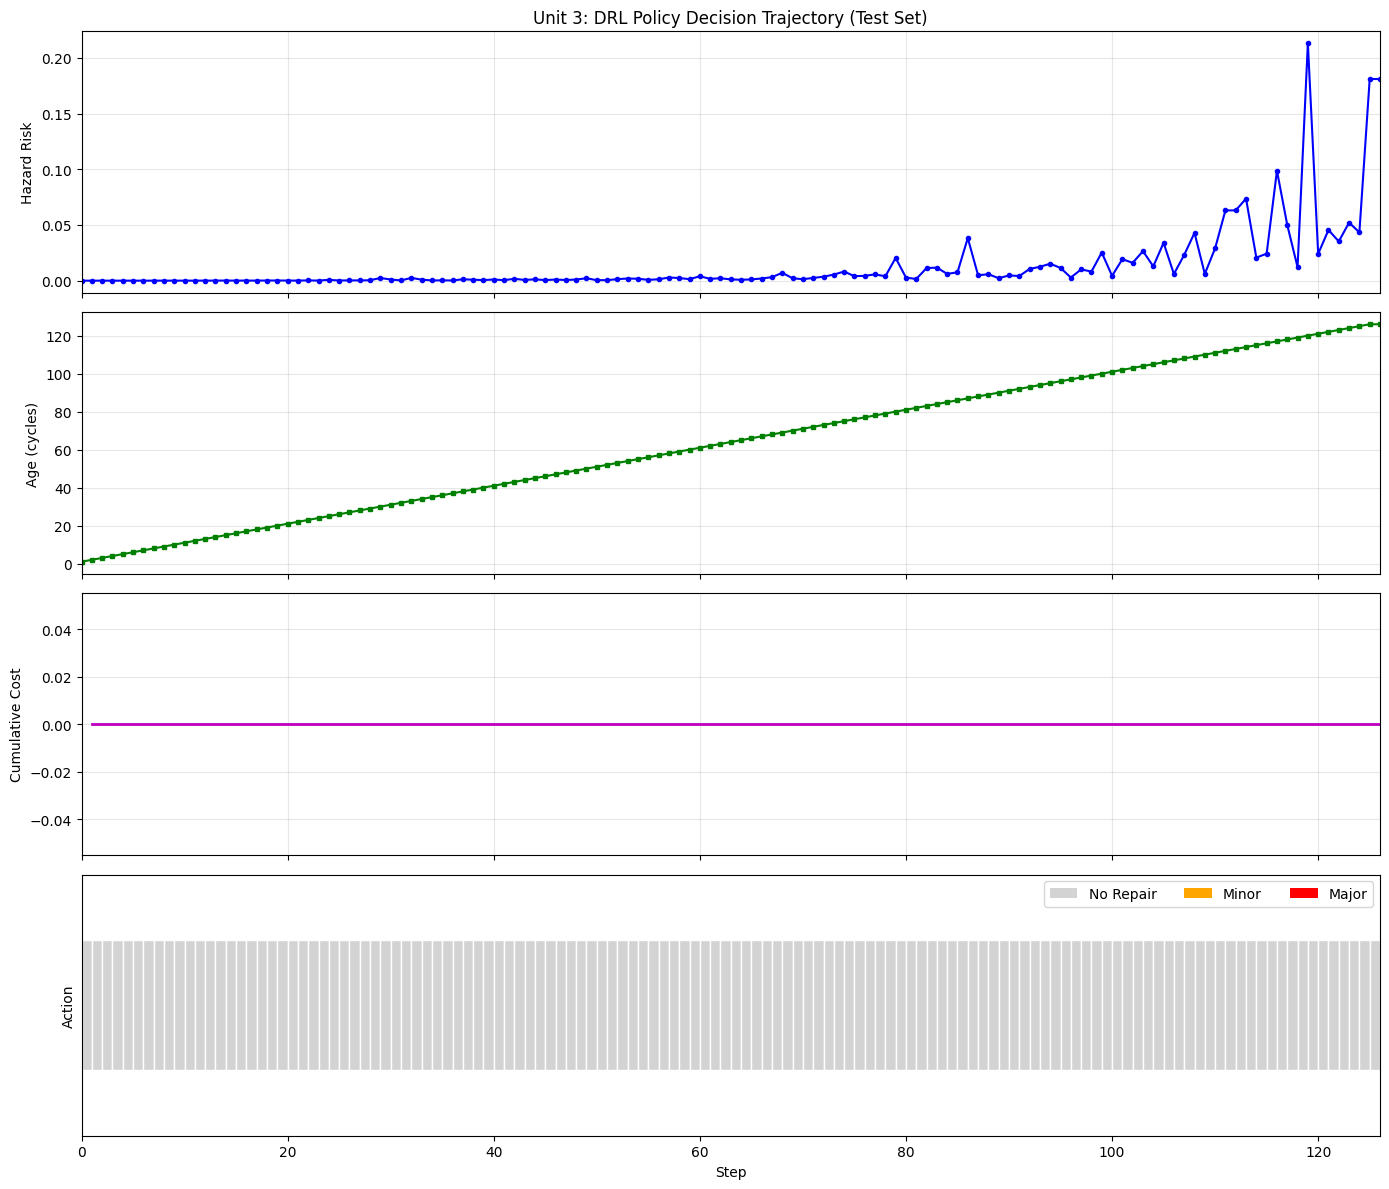


轨迹统计 (Unit 3):
  总步数: 126
  总成本: 0
  动作分布: No=126, Minor=0, Major=0


In [46]:
# ==========================================
# DRL 15. 单轨迹决策可视化 (修复版)
# ==========================================

def visualize_drl_trajectory(unit_id, environment, policy_fn, save_fig=False):
    """
    可视化单个 unit 在 DRL 策略下的决策轨迹

    Args:
        unit_id: unit ID
        environment: MaintenanceEnv 实例
        policy_fn: 策略函数
        save_fig: 是否保存图片
    """
    if unit_id not in environment.units:
        print(f"Unit {unit_id} 不存在于环境中")
        return

    state = environment.reset(unit_id=unit_id)

    h_history = [state[0] * environment.h_max]
    age_history = [state[1] * environment.age_max]
    actions_hist = []
    rewards_hist = []

    while not environment.done:
        action = policy_fn(state)
        next_state, reward, done, info = environment.step(action)

        actions_hist.append(action)
        rewards_hist.append(reward)
        h_history.append(next_state[0] * environment.h_max)
        age_history.append(next_state[1] * environment.age_max)

        state = next_state

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    steps = range(len(h_history))

    # 1) Hazard Risk 轨迹
    ax1 = axes[0]
    ax1.plot(steps, h_history, 'b-', linewidth=1.5, marker='o', markersize=3)
    ax1.set_ylabel("Hazard Risk")
    ax1.set_title(f"Unit {unit_id}: DRL Policy Decision Trajectory (Test Set)")
    ax1.grid(True, alpha=0.3)

    # 标注动作
    for i, a in enumerate(actions_hist):
        if a == 1:  # Minor
            ax1.axvline(i+1, color='orange', alpha=0.5, linestyle='--')
        elif a == 2:  # Major
            ax1.axvline(i+1, color='red', alpha=0.7, linestyle='-', linewidth=2)

    # 2) Age 轨迹
    ax2 = axes[1]
    ax2.plot(steps, age_history, 'g-', linewidth=1.5, marker='s', markersize=3)
    ax2.set_ylabel("Age (cycles)")
    ax2.grid(True, alpha=0.3)

    # 3) 累积成本 (还原实际成本: reward 是 shifted 后的值)
    ax3 = axes[2]
    # 实际成本 = -R_action[action]
    actual_costs = [-R_action[a] for a in actions_hist]
    cumulative_cost = np.cumsum(actual_costs)
    ax3.plot(range(1, len(cumulative_cost)+1), cumulative_cost, 'm-', linewidth=2)
    ax3.fill_between(range(1, len(cumulative_cost)+1), 0, cumulative_cost, alpha=0.3, color='magenta')
    ax3.set_ylabel("Cumulative Cost")
    ax3.grid(True, alpha=0.3)

    # 4) 动作时间线
    ax4 = axes[3]
    action_colors = {0: 'lightgray', 1: 'orange', 2: 'red'}
    action_labels = {0: 'No Repair', 1: 'Minor', 2: 'Major'}

    for i, a in enumerate(actions_hist):
        ax4.barh(0, 1, left=i, height=0.5, color=action_colors[a], edgecolor='white')

    ax4.set_xlim(0, len(actions_hist))
    ax4.set_ylim(-0.5, 0.5)
    ax4.set_xlabel("Step")
    ax4.set_ylabel("Action")
    ax4.set_yticks([])

    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=action_colors[a], label=action_labels[a]) for a in [0, 1, 2]]
    ax4.legend(handles=legend_elements, loc='upper right', ncol=3)

    plt.tight_layout()

    if save_fig:
        plt.savefig(f"drl_trajectory_unit_{unit_id}.png", dpi=150)

    plt.show()

    # 统计
    print(f"\n轨迹统计 (Unit {unit_id}):")
    print(f"  总步数: {len(actions_hist)}")
    print(f"  总成本: {sum(actual_costs):.0f}")
    print(f"  动作分布: No={actions_hist.count(0)}, Minor={actions_hist.count(1)}, Major={actions_hist.count(2)}")

# 可视化几个样例 unit
print("=" * 60)
print("DRL 决策轨迹可视化示例 (测试集)")
print("=" * 60)

# 【修复】使用 test_unit_ids 和 env_test, drl_greedy_action
sample_units = test_unit_ids[:3]
for uid in sample_units:
    visualize_drl_trajectory(uid, env_test, drl_greedy_action, save_fig=True)

In [47]:
# ==========================================
# DRL 16. 综合评估指标与模型总结 (修复版)
# ==========================================

print("=" * 80)
print("DRL 维护决策模型 - 综合评估报告")
print("=" * 80)

# 1. 训练指标
print("\n【1. 训练指标】")
print("-" * 40)
print(f"  训练 Epochs: {DRL_EPOCHS}")
print(f"  最终 Loss: {train_losses[-1]:.6f}")
print(f"  Loss 变化: {train_losses[0]:.6f} → {train_losses[-1]:.6f} ({(1 - train_losses[-1]/train_losses[0])*100:.1f}% 下降)")
print(f"  最终平均成本: {train_episode_costs[-1]:.2f}")

# 2. 测试集表现
print("\n【2. 测试集表现】")
print("-" * 40)
print(f"  测试 Units 数: {len(test_unit_ids)}")
drl_costs_arr = np.array(drl_results['unit_costs'])
drl_steps_arr = np.array(drl_results['unit_steps'])
print(f"  DRL 平均成本: {drl_costs_arr.mean():.2f} ± {drl_costs_arr.std():.2f}")
print(f"  DRL 成本范围: [{drl_costs_arr.min():.0f}, {drl_costs_arr.max():.0f}]")
print(f"  平均 Episode 长度: {drl_steps_arr.mean():.1f}")

# 3. 与基线对比
print("\n【3. 策略对比】")
print("-" * 40)
comparisons = [
    ("No Maintenance", np.array(no_maint_results['unit_costs']).mean()),
    ("Always Minor", np.array(minor_results['unit_costs']).mean()),
    ("Threshold", np.array(threshold_results['unit_costs']).mean())
]
drl_mean = drl_costs_arr.mean()

for name, baseline_cost in comparisons:
    improvement = (baseline_cost - drl_mean) / baseline_cost * 100 if baseline_cost > 0 else 0
    symbol = "↓" if improvement > 0 else "↑"
    print(f"  vs {name:<15}: {improvement:+.1f}% {symbol}")

# 4. 动作分布分析
print("\n【4. 动作分布】")
print("-" * 40)
total_actions = drl_results['action_counts'].sum()
print(f"  No Repair: {drl_results['action_counts'][0]:>6.0f} ({drl_results['action_counts'][0]/total_actions*100:.1f}%)")
print(f"  Minor:     {drl_results['action_counts'][1]:>6.0f} ({drl_results['action_counts'][1]/total_actions*100:.1f}%)")
print(f"  Major:     {drl_results['action_counts'][2]:>6.0f} ({drl_results['action_counts'][2]/total_actions*100:.1f}%)")

# 5. 成本效率分析
print("\n【5. 成本效率】")
print("-" * 40)
# 计算每个动作的平均成本贡献
action_costs = np.array([0, 20, 40])  # 原始成本
avg_action_cost = np.sum(drl_results['action_counts'] * action_costs) / total_actions
print(f"  平均动作成本: {avg_action_cost:.2f}")
print(f"  总动作数: {total_actions:.0f}")
print(f"  总成本: {drl_costs_arr.sum():.0f}")

# 6. 综合评分 (自定义)
print("\n【6. 综合评分】")
print("-" * 40)

# 评分标准:
# - 成本效率 (0-40分): 相对于最差策略的改进
# - 策略合理性 (0-30分): Major repair 主要发生在低 RUL 时
# - 训练收敛性 (0-30分): Loss 下降程度

# 成本效率分数
baseline_costs = [
    np.array(no_maint_results['unit_costs']).mean(),
    np.array(minor_results['unit_costs']).mean(),
    np.array(threshold_results['unit_costs']).mean()
]
worst_cost = max(baseline_costs)
best_possible_cost = 40  # 理论最低 (只做一次 major repair)
cost_efficiency = (worst_cost - drl_mean) / (worst_cost - best_possible_cost) * 40 if worst_cost > best_possible_cost else 20
cost_efficiency = np.clip(cost_efficiency, 0, 40)

# 策略合理性分数 (假设低 RUL 时 major 比例应该更高)
try:
    if len(rul_action_matrix) > 0:
        # 检查是否 RUL 越低，Major 比例越高
        major_probs = rul_action_matrix[:, 2]
        # 理想情况是降序排列
        from scipy.stats import spearmanr
        # RUL 从低到高，major 应该从高到低
        corr, _ = spearmanr(range(len(major_probs)), -major_probs)
        rationality = max(0, corr) * 30
    else:
        rationality = 15  # 中等分数
except:
    rationality = 15

# 训练收敛性分数
convergence = min(30, (1 - train_losses[-1]/train_losses[0]) * 50)

total_score = cost_efficiency + rationality + convergence

print(f"  成本效率得分:    {cost_efficiency:.1f}/40")
print(f"  策略合理性得分:  {rationality:.1f}/30")
print(f"  训练收敛性得分:  {convergence:.1f}/30")
print(f"  ---------------------------")
print(f"  综合得分:        {total_score:.1f}/100")

# 等级评定
if total_score >= 80:
    grade = "A (优秀)"
elif total_score >= 60:
    grade = "B (良好)"
elif total_score >= 40:
    grade = "C (一般)"
else:
    grade = "D (需改进)"

print(f"  评级:            {grade}")

print("\n" + "=" * 80)
print("评估完成")
print("=" * 80)

DRL 维护决策模型 - 综合评估报告

【1. 训练指标】
----------------------------------------
  训练 Epochs: 200
  最终 Loss: 0.001676
  Loss 变化: 0.176811 → 0.001676 (99.1% 下降)
  最终平均成本: 18.24

【2. 测试集表现】
----------------------------------------
  测试 Units 数: 707
  DRL 平均成本: 0.00 ± 0.00
  DRL 成本范围: [0, 0]
  平均 Episode 长度: 134.9

【3. 策略对比】
----------------------------------------
  vs No Maintenance : +0.0% ↑
  vs Always Minor   : +100.0% ↓
  vs Threshold      : +100.0% ↓

【4. 动作分布】
----------------------------------------
  No Repair:  95342 (100.0%)
  Minor:          0 (0.0%)
  Major:          0 (0.0%)

【5. 成本效率】
----------------------------------------
  平均动作成本: 0.00
  总动作数: 95342
  总成本: 0

【6. 综合评分】
----------------------------------------
  成本效率得分:    40.0/40
  策略合理性得分:  0.0/30
  训练收敛性得分:  30.0/30
  ---------------------------
  综合得分:        70.0/100
  评级:            B (良好)

评估完成


/tmp/ipython-input-921489506.py:88: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(range(len(major_probs)), -major_probs)


In [48]:
import json
from datetime import datetime

# 保存模型权重
model_path = "drl_maintenance_model.pth"
torch.save({
    'epoch': DRL_EPOCHS,
    'model_state_dict': q_net.state_dict(),
    'target_state_dict': target_net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, model_path)
print(f"模型已保存到: {model_path}")

# 【修复】使用正确的变量名构建训练历史
history = {
    'train_losses': train_losses,
    'train_episode_costs': train_episode_costs,
    'train_action_counts': [list(map(int, c)) for c in train_action_counts],
    'test_results': {
        'drl_costs': drl_results['unit_costs'],
        'drl_actions': list(map(int, drl_results['action_counts'])),
        'drl_avg_cost': float(drl_results['avg_cost']),
        'no_maint_avg_cost': float(no_maint_results['avg_cost']),
        'minor_avg_cost': float(minor_results['avg_cost']),
        'threshold_avg_cost': float(threshold_results['avg_cost']),
    },
    'hyperparameters': {
        'epochs': DRL_EPOCHS,
        'gamma': DRL_GAMMA,
        'lr': DRL_LR,
        'batch_size': DRL_BATCH_SIZE,
        'buffer_size': DRL_BUFFER_SIZE,
        'hidden_dim': 512,
        'reward_shift': float(REWARD_SHIFT),
    },
    'timestamp': datetime.now().isoformat()
}

history_path = "drl_training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"训练历史已保存到: {history_path}")

print("\n保存的文件列表:")
print("  - drl_maintenance_model.pth (模型权重)")
print("  - drl_training_history.json (训练历史)")
print("  - drl_training_curves.png (训练曲线)")
print("  - drl_policy_comparison.png (策略对比)")
print("  - drl_rul_analysis.png (RUL 分析)")
print("  - drl_trajectory_unit_*.png (轨迹可视化)")

模型已保存到: drl_maintenance_model.pth
训练历史已保存到: drl_training_history.json

保存的文件列表:
  - drl_maintenance_model.pth (模型权重)
  - drl_training_history.json (训练历史)
  - drl_training_curves.png (训练曲线)
  - drl_policy_comparison.png (策略对比)
  - drl_rul_analysis.png (RUL 分析)
  - drl_trajectory_unit_*.png (轨迹可视化)


In [49]:
# ==========================================
# DRL 17. 保存模型和训练结果 (修复版)
# ==========================================

import json
from datetime import datetime

# 保存模型权重
model_path = "drl_maintenance_model.pth"
torch.save({
    'epoch': DRL_EPOCHS,
    'model_state_dict': q_net.state_dict(),
    'target_state_dict': target_net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, model_path)
print(f"模型已保存到: {model_path}")

# 【修复】使用正确的变量名构建训练历史
history = {
    'train_losses': train_losses,
    'train_episode_costs': train_episode_costs,
    'train_action_counts': [list(map(int, c)) for c in train_action_counts],
    'test_results': {
        'drl_costs': drl_results['unit_costs'],
        'drl_actions': list(map(int, drl_results['action_counts'])),
        'drl_avg_cost': float(drl_results['avg_cost']),
        'no_maint_avg_cost': float(no_maint_results['avg_cost']),
        'minor_avg_cost': float(minor_results['avg_cost']),
        'threshold_avg_cost': float(threshold_results['avg_cost']),
    },
    'hyperparameters': {
        'epochs': DRL_EPOCHS,
        'gamma': DRL_GAMMA,
        'lr': DRL_LR,
        'batch_size': DRL_BATCH_SIZE,
        'buffer_size': DRL_BUFFER_SIZE,
        'hidden_dim': 512,
        'reward_shift': float(REWARD_SHIFT),
    },
    'timestamp': datetime.now().isoformat()
}

history_path = "drl_training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"训练历史已保存到: {history_path}")

print("\n保存的文件列表:")
print("  - drl_maintenance_model.pth (模型权重)")
print("  - drl_training_history.json (训练历史)")
print("  - drl_training_curves.png (训练曲线)")
print("  - drl_policy_comparison.png (策略对比)")
print("  - drl_rul_analysis.png (RUL 分析)")
print("  - drl_trajectory_unit_*.png (轨迹可视化)")

模型已保存到: drl_maintenance_model.pth
训练历史已保存到: drl_training_history.json

保存的文件列表:
  - drl_maintenance_model.pth (模型权重)
  - drl_training_history.json (训练历史)
  - drl_training_curves.png (训练曲线)
  - drl_policy_comparison.png (策略对比)
  - drl_rul_analysis.png (RUL 分析)
  - drl_trajectory_unit_*.png (轨迹可视化)
